# Multiple Disease Prediction System using Machine Learning Technique


## Step 1 — Install & Import Libraries

In [ ]:
!pip install shap imbalanced-learn --quiet

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, gc, copy

from sklearn.preprocessing     import LabelEncoder, StandardScaler
from sklearn.impute            import SimpleImputer
from sklearn.model_selection   import (train_test_split, cross_val_score,
                                        StratifiedKFold, GridSearchCV)
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm               import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics           import (accuracy_score, precision_score, recall_score,
                                        f1_score, roc_auc_score, confusion_matrix,
                                        classification_report, roc_curve)
from imblearn.over_sampling    import SMOTE
import shap

sns.set_style("whitegrid")
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
print("All libraries loaded.")

All libraries loaded.


## Step 2 — Load Datasets

In [ ]:
from google.colab import files
print("Upload: diabetes.csv, heart_disease_uci.csv, kidney_disease.csv")
uploaded = files.upload()

Upload: diabetes.csv, heart_disease_uci.csv, kidney_disease.csv


Saving kidney_disease.csv to kidney_disease (1).csv
Saving heart_disease_uci.csv to heart_disease_uci (1).csv
Saving diabetes.csv to diabetes (1).csv


In [ ]:
df_dia = pd.read_csv('diabetes.csv')
df_hrt = pd.read_csv('heart_disease_uci.csv')
df_kid = pd.read_csv('kidney_disease.csv')

print(f"Diabetes      : {df_dia.shape[0]} rows x {df_dia.shape[1]} cols")
print(f"Heart Disease : {df_hrt.shape[0]} rows x {df_hrt.shape[1]} cols")
print(f"Kidney Disease: {df_kid.shape[0]} rows x {df_kid.shape[1]} cols")

Diabetes      : 768 rows x 9 cols
Heart Disease : 920 rows x 16 cols
Kidney Disease: 400 rows x 26 cols


### 2.1 Quick Preview

In [ ]:
print("-- Diabetes (first 3 rows) --")
display(df_dia.head(3))
print("\n-- Heart Disease (first 3 rows) --")
display(df_hrt.head(3))
print("\n-- Kidney Disease (first 3 rows) --")
display(df_kid.head(3))

-- Diabetes (first 3 rows) --


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1



-- Heart Disease (first 3 rows) --


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1



-- Kidney Disease (first 3 rows) --


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.02,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.02,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.01,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd


### 2.2 Missing Values Summary

In [ ]:
for df, name in [(df_dia, "Diabetes"), (df_hrt, "Heart Disease"), (df_kid, "Kidney Disease")]:
    print(f"\n{'='*5}  {name}")
    print(f"  Shape  : {df.shape}")
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing):
        print(f"  Missing values:\n{missing.to_string()}")
    else:
        print("  Missing values: None")


=====  Diabetes
  Shape  : (768, 9)
  Missing values: None

=====  Heart Disease
  Shape  : (920, 16)
  Missing values:
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486

=====  Kidney Disease
  Shape  : (400, 26)
  Missing values:
age        9
bp        12
sg        47
al        46
su        49
rbc      152
pc        65
pcc        4
ba         4
bgr       44
bu        19
sc        17
sod       87
pot       88
hemo      52
pcv       70
wc       105
rc       130
htn        2
dm         2
cad        2
appet      1
pe         1
ane        1


## Step 3 — Exploratory Data Analysis (EDA)

### 3.1 — Class Distribution (All Three Datasets)

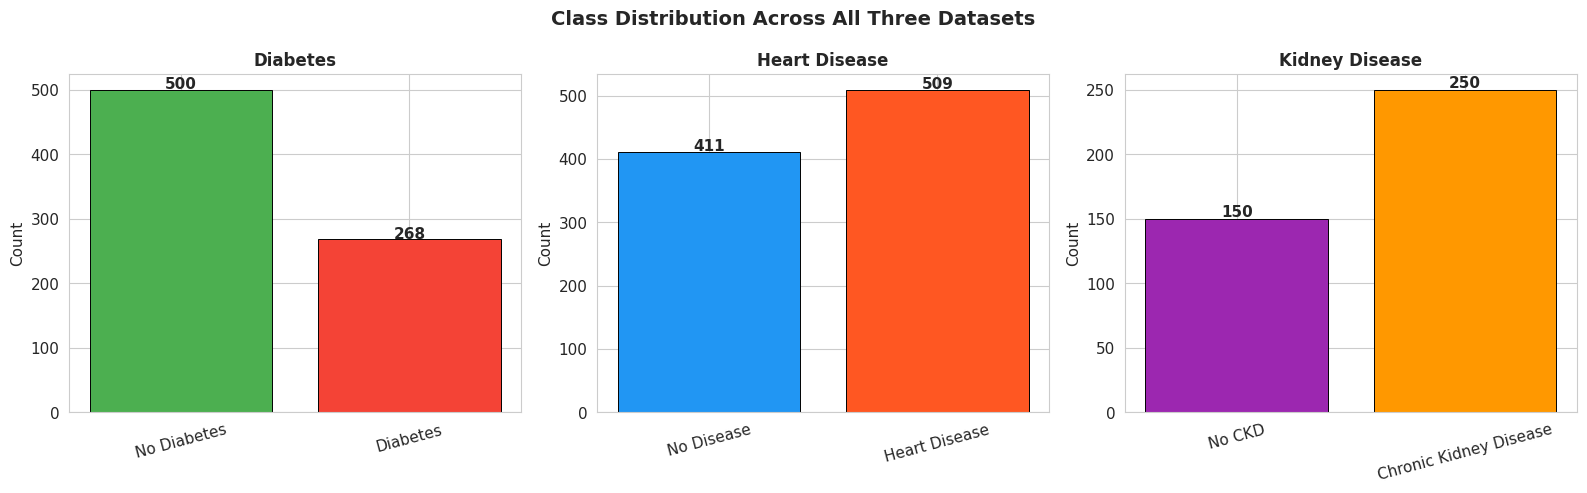

In [ ]:
df_hrt['target'] = (df_hrt['num'] > 0).astype(int)
df_kid['classification'] = df_kid['classification'].str.strip()
df_kid['target_k'] = (df_kid['classification'] == 'ckd').astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Class Distribution Across All Three Datasets", fontsize=14, fontweight='bold')

datasets_plot = [
    (df_dia, 'Outcome',   ['No Diabetes','Diabetes'],               ['#4CAF50','#F44336'], 'Diabetes'),
    (df_hrt, 'target',    ['No Disease','Heart Disease'],           ['#2196F3','#FF5722'], 'Heart Disease'),
    (df_kid, 'target_k',  ['No CKD','Chronic Kidney Disease'],     ['#9C27B0','#FF9800'], 'Kidney Disease'),
]

for ax, (df, col, labels, colors, title) in zip(axes, datasets_plot):
    c = df[col].value_counts().sort_index()
    bars = ax.bar(labels[:len(c)], c.values, color=colors, edgecolor='black', linewidth=0.7)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel('Count')
    for b, v in zip(bars, c.values):
        ax.text(b.get_x()+b.get_width()/2, v+2, str(v), ha='center', fontweight='bold')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### 3.2 — Histogram + KDE

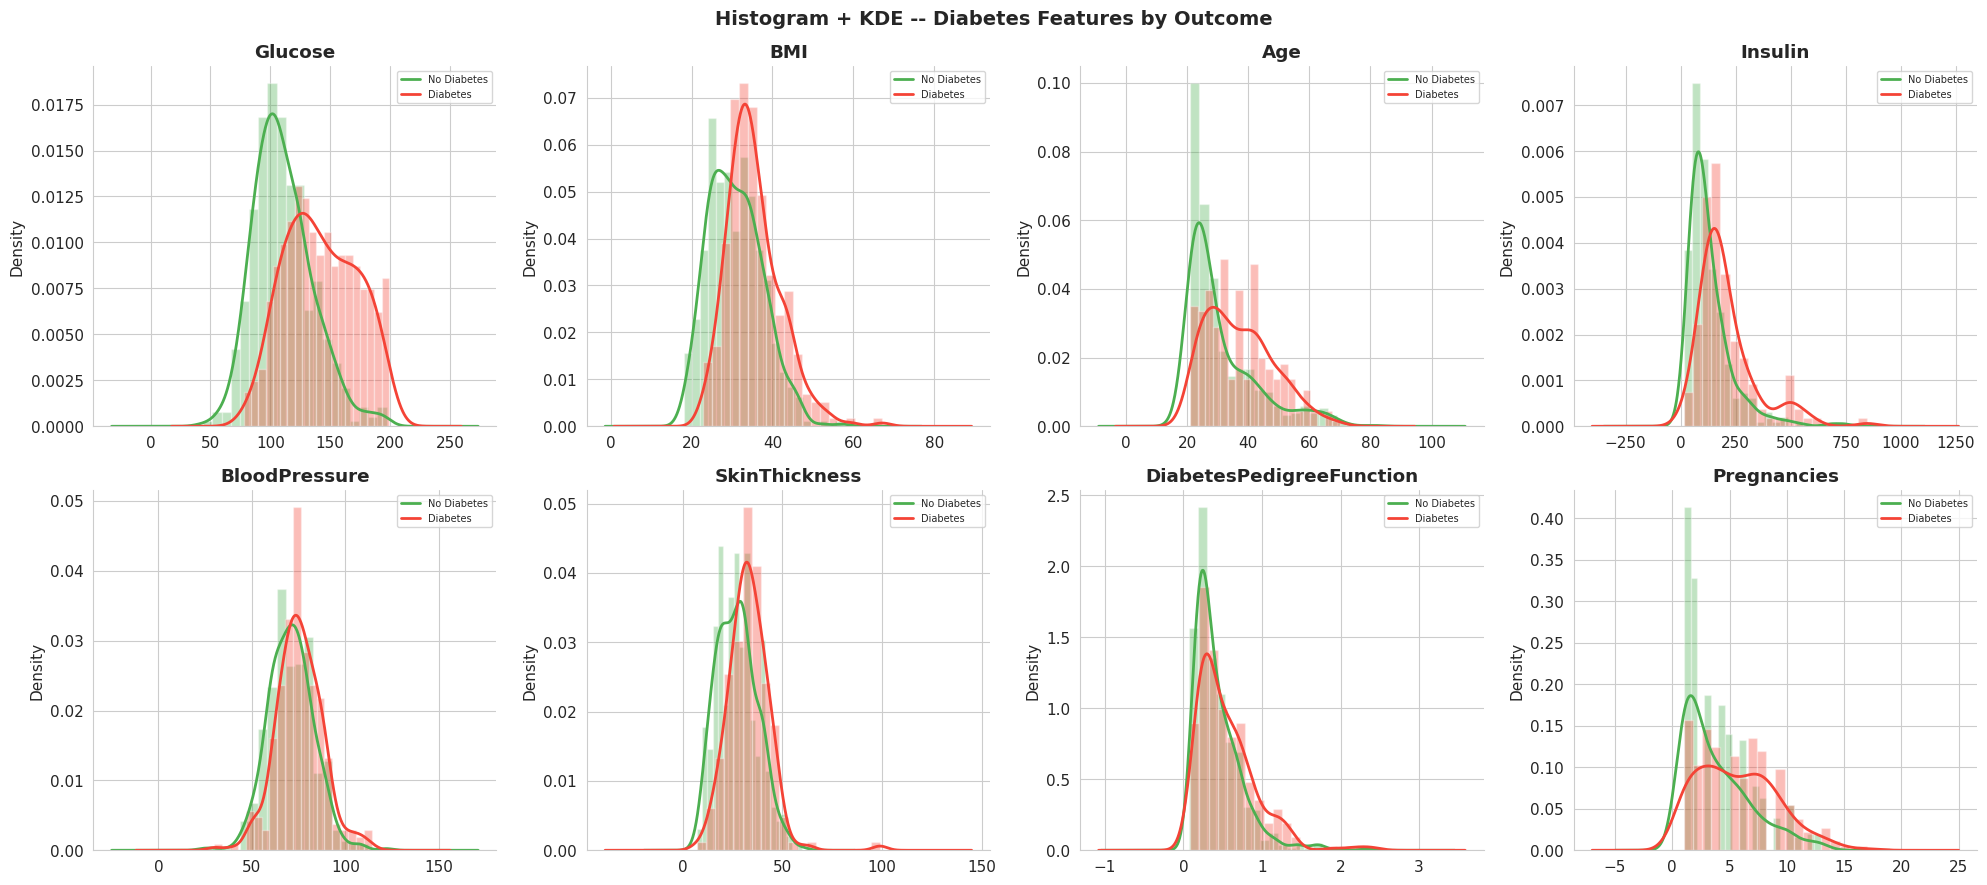

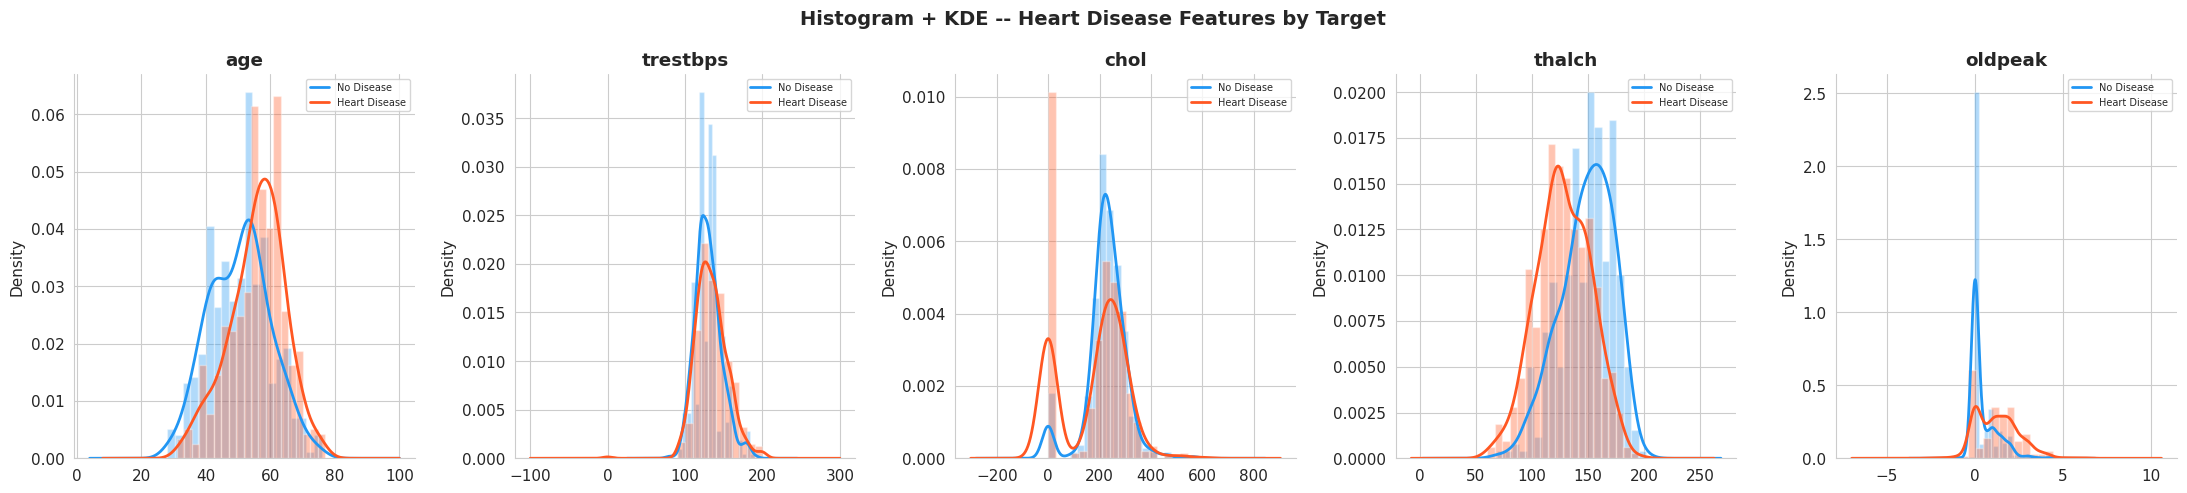

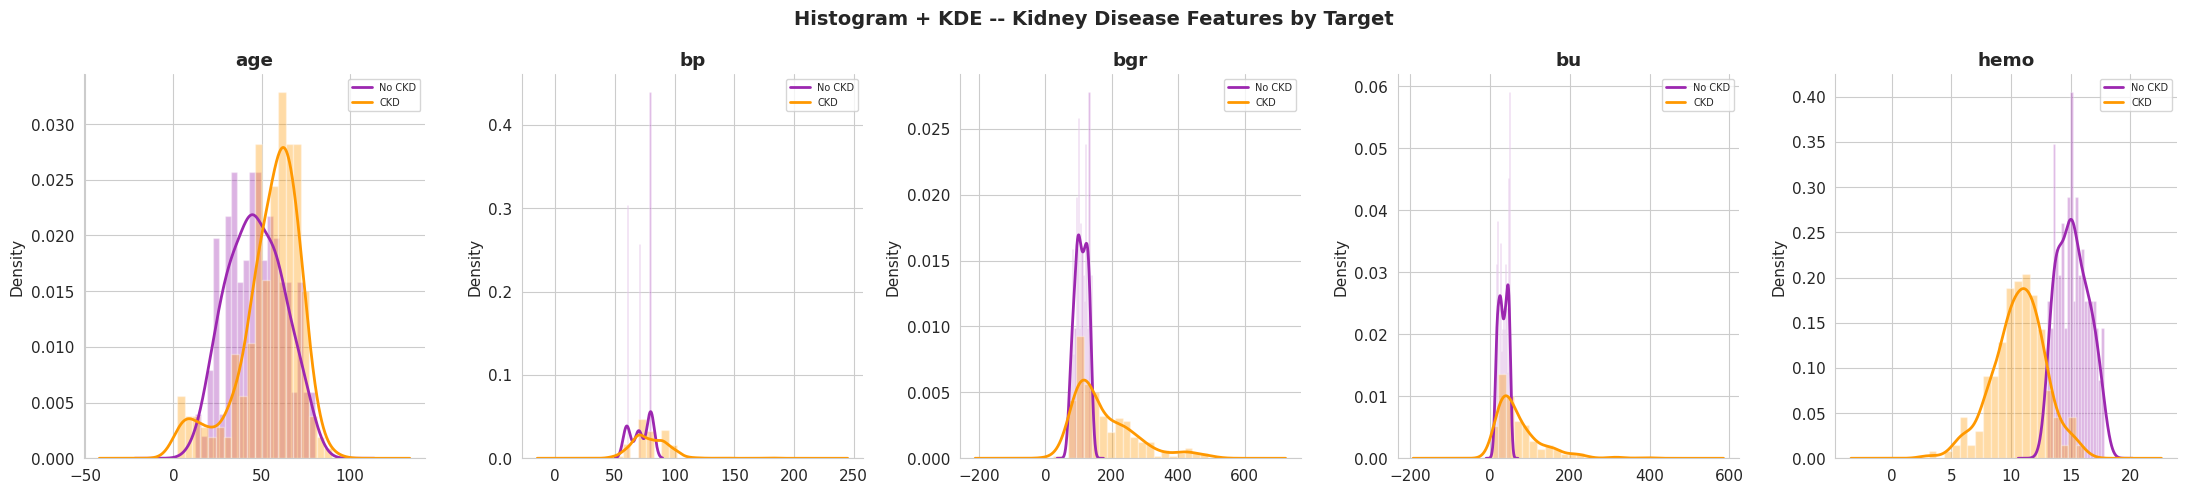

In [ ]:
# Diabetes
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle("Histogram + KDE -- Diabetes Features by Outcome", fontsize=14, fontweight='bold')
for ax, col in zip(axes.flat, ['Glucose','BMI','Age','Insulin','BloodPressure','SkinThickness','DiabetesPedigreeFunction','Pregnancies']):
    for lbl,color,name in [(0,'#4CAF50','No Diabetes'),(1,'#F44336','Diabetes')]:
        d = df_dia[df_dia['Outcome']==lbl][col].replace(0,np.nan).dropna()
        ax.hist(d, bins=20, alpha=0.35, color=color, density=True)
        try: d.plot.kde(ax=ax, color=color, lw=2, label=name)
        except: pass
    ax.set_title(col, fontweight='bold'); ax.legend(fontsize=7)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Heart Disease
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle("Histogram + KDE -- Heart Disease Features by Target", fontsize=14, fontweight='bold')
for ax, col in zip(axes, ['age','trestbps','chol','thalch','oldpeak']):
    for lbl,color,name in [(0,'#2196F3','No Disease'),(1,'#FF5722','Heart Disease')]:
        d = df_hrt[df_hrt['target']==lbl][col].dropna()
        ax.hist(d, bins=20, alpha=0.35, color=color, density=True)
        try: d.plot.kde(ax=ax, color=color, lw=2, label=name)
        except: pass
    ax.set_title(col, fontweight='bold'); ax.legend(fontsize=7)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Kidney Disease
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle("Histogram + KDE -- Kidney Disease Features by Target", fontsize=14, fontweight='bold')
for ax, col in zip(axes, ['age','bp','bgr','bu','hemo']):
    for lbl,color,name in [(0,'#9C27B0','No CKD'),(1,'#FF9800','CKD')]:
        d = pd.to_numeric(df_kid[df_kid['target_k']==lbl][col], errors='coerce').dropna()
        ax.hist(d, bins=20, alpha=0.35, color=color, density=True)
        try: d.plot.kde(ax=ax, color=color, lw=2, label=name)
        except: pass
    ax.set_title(col, fontweight='bold'); ax.legend(fontsize=7)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### 3.3 — Box Plots

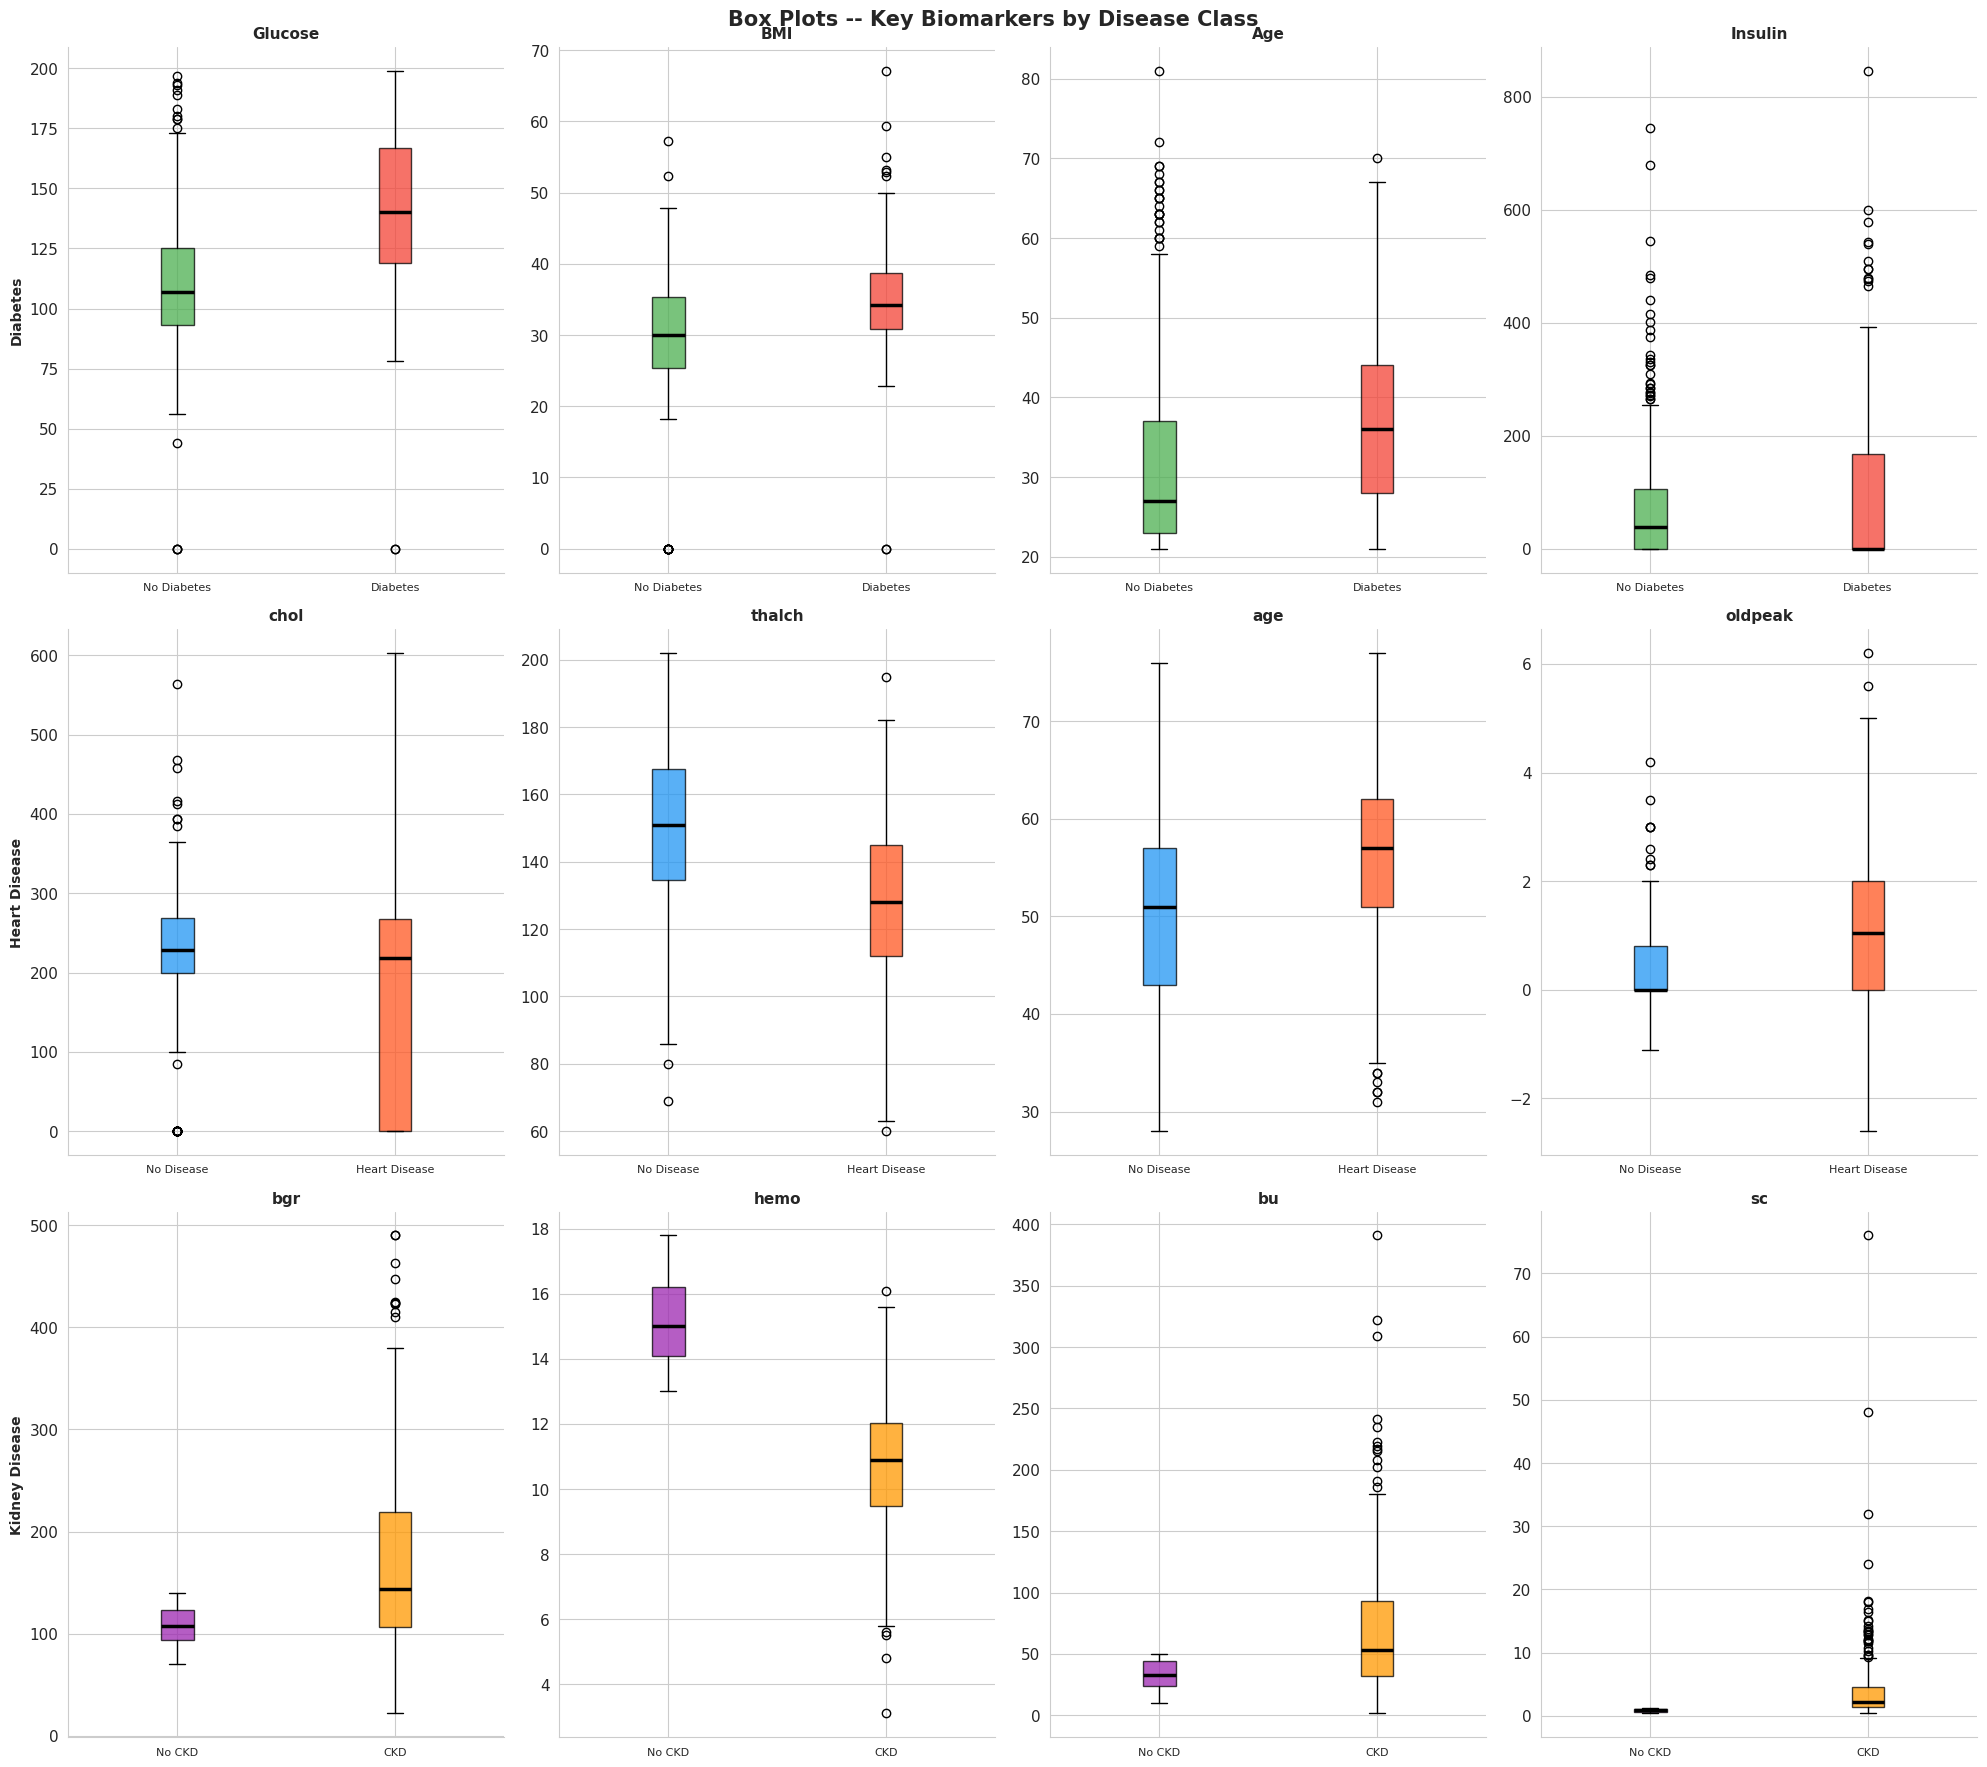

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(20, 18))
fig.suptitle("Box Plots -- Key Biomarkers by Disease Class", fontsize=15, fontweight='bold')

rows = [
    [(df_dia,'Outcome','Glucose',['No Diabetes','Diabetes'],['#4CAF50','#F44336']),
     (df_dia,'Outcome','BMI',    ['No Diabetes','Diabetes'],['#4CAF50','#F44336']),
     (df_dia,'Outcome','Age',    ['No Diabetes','Diabetes'],['#4CAF50','#F44336']),
     (df_dia,'Outcome','Insulin',['No Diabetes','Diabetes'],['#4CAF50','#F44336'])],
    [(df_hrt,'target','chol',   ['No Disease','Heart Disease'],['#2196F3','#FF5722']),
     (df_hrt,'target','thalch', ['No Disease','Heart Disease'],['#2196F3','#FF5722']),
     (df_hrt,'target','age',    ['No Disease','Heart Disease'],['#2196F3','#FF5722']),
     (df_hrt,'target','oldpeak',['No Disease','Heart Disease'],['#2196F3','#FF5722'])],
    [(df_kid,'target_k','bgr',  ['No CKD','CKD'],['#9C27B0','#FF9800']),
     (df_kid,'target_k','hemo', ['No CKD','CKD'],['#9C27B0','#FF9800']),
     (df_kid,'target_k','bu',   ['No CKD','CKD'],['#9C27B0','#FF9800']),
     (df_kid,'target_k','sc',   ['No CKD','CKD'],['#9C27B0','#FF9800'])],
]
row_names = ['Diabetes', 'Heart Disease', 'Kidney Disease']

for r, row_data in enumerate(rows):
    for c, (df,tcol,feat,labels,colors) in enumerate(row_data):
        ax = axes[r][c]
        data = [pd.to_numeric(df[df[tcol]==t][feat], errors='coerce').dropna() for t in [0,1]]
        bp = ax.boxplot(data, patch_artist=True, labels=labels, medianprops=dict(color='black',linewidth=2.5))
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color); patch.set_alpha(0.75)
        ax.set_title(feat, fontweight='bold', fontsize=11)
        ax.tick_params(axis='x', labelsize=8)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        if c == 0: ax.set_ylabel(row_names[r], fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### 3.4 — Violin Plots

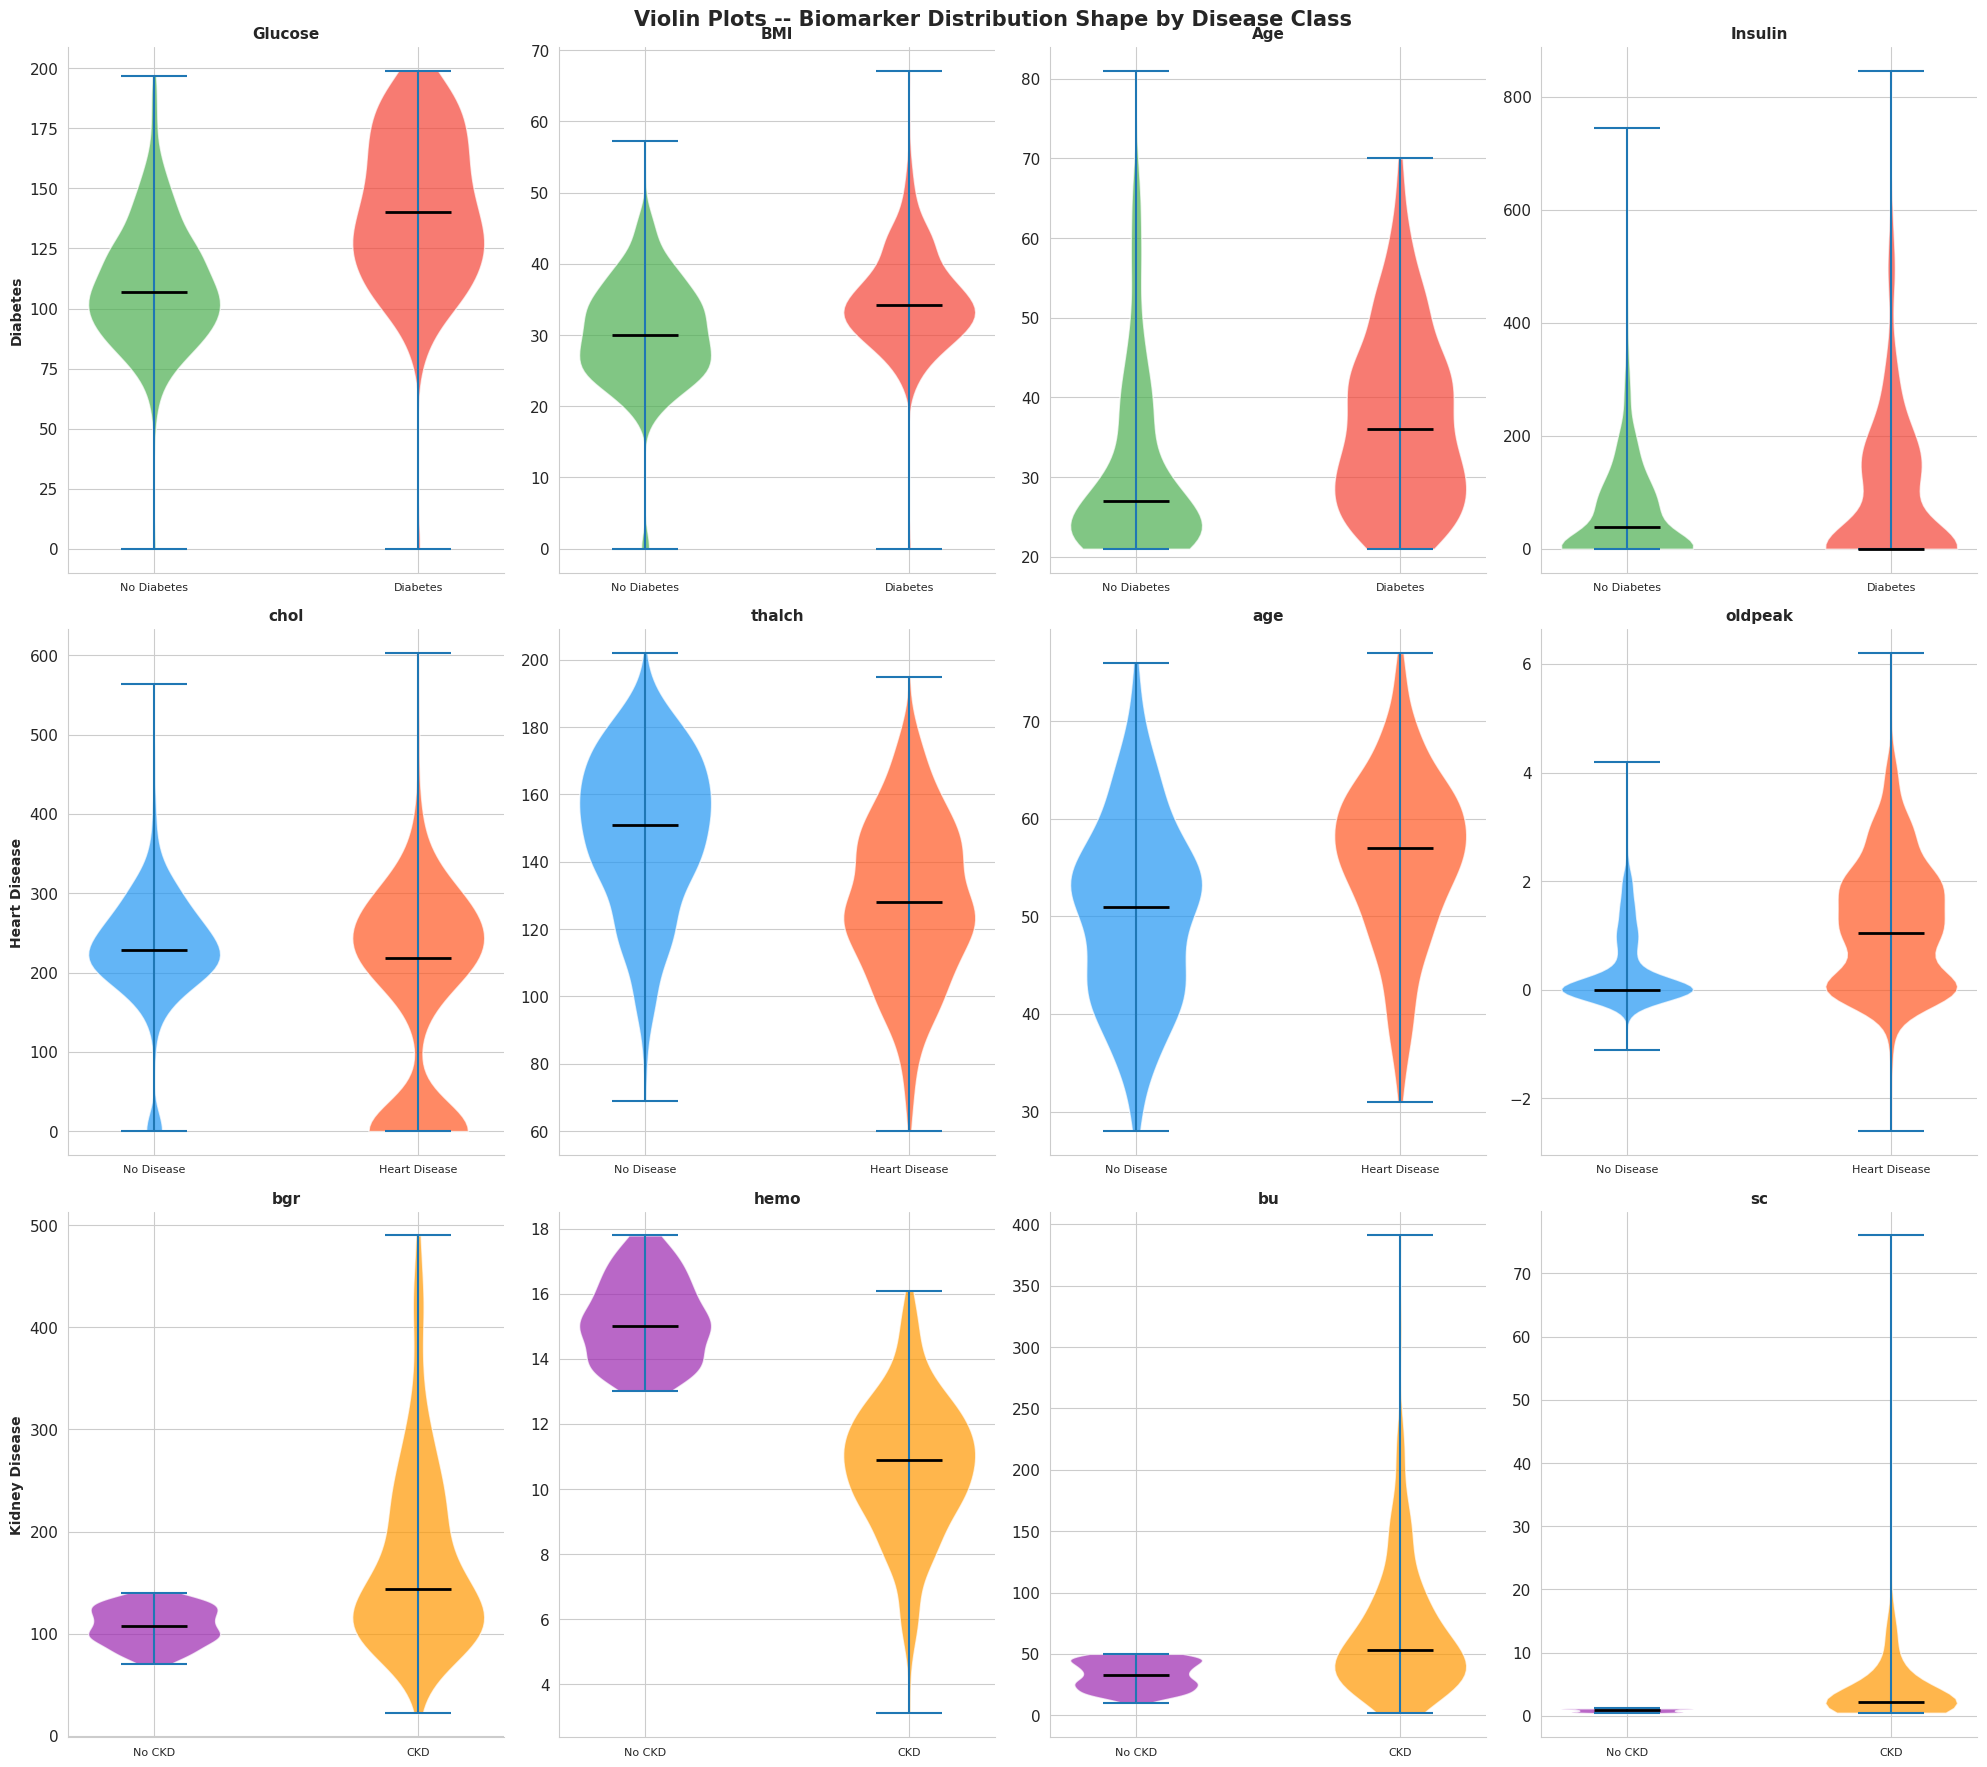

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(20, 18))
fig.suptitle("Violin Plots -- Biomarker Distribution Shape by Disease Class", fontsize=15, fontweight='bold')

rows = [
    (df_dia,'Outcome',['Glucose','BMI','Age','Insulin'],
     ['No Diabetes','Diabetes'],['#4CAF50','#F44336'],'Diabetes'),
    (df_hrt,'target',['chol','thalch','age','oldpeak'],
     ['No Disease','Heart Disease'],['#2196F3','#FF5722'],'Heart Disease'),
    (df_kid,'target_k',['bgr','hemo','bu','sc'],
     ['No CKD','CKD'],['#9C27B0','#FF9800'],'Kidney Disease'),
]

for r,(df,tcol,feats,labels,colors,row_label) in enumerate(rows):
    for c, feat in enumerate(feats):
        ax = axes[r][c]
        data = [pd.to_numeric(df[df[tcol]==t][feat], errors='coerce').dropna() for t in [0,1]]
        parts = ax.violinplot(data, positions=[1,2], showmedians=True, showextrema=True)
        for pc, color in zip(parts['bodies'], colors):
            pc.set_facecolor(color); pc.set_alpha(0.7)
        parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)
        ax.set_xticks([1,2]); ax.set_xticklabels(labels, fontsize=8)
        ax.set_title(feat, fontweight='bold', fontsize=11)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        if c == 0: ax.set_ylabel(row_label, fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### 3.5 — KDE Plots (Class Separation)

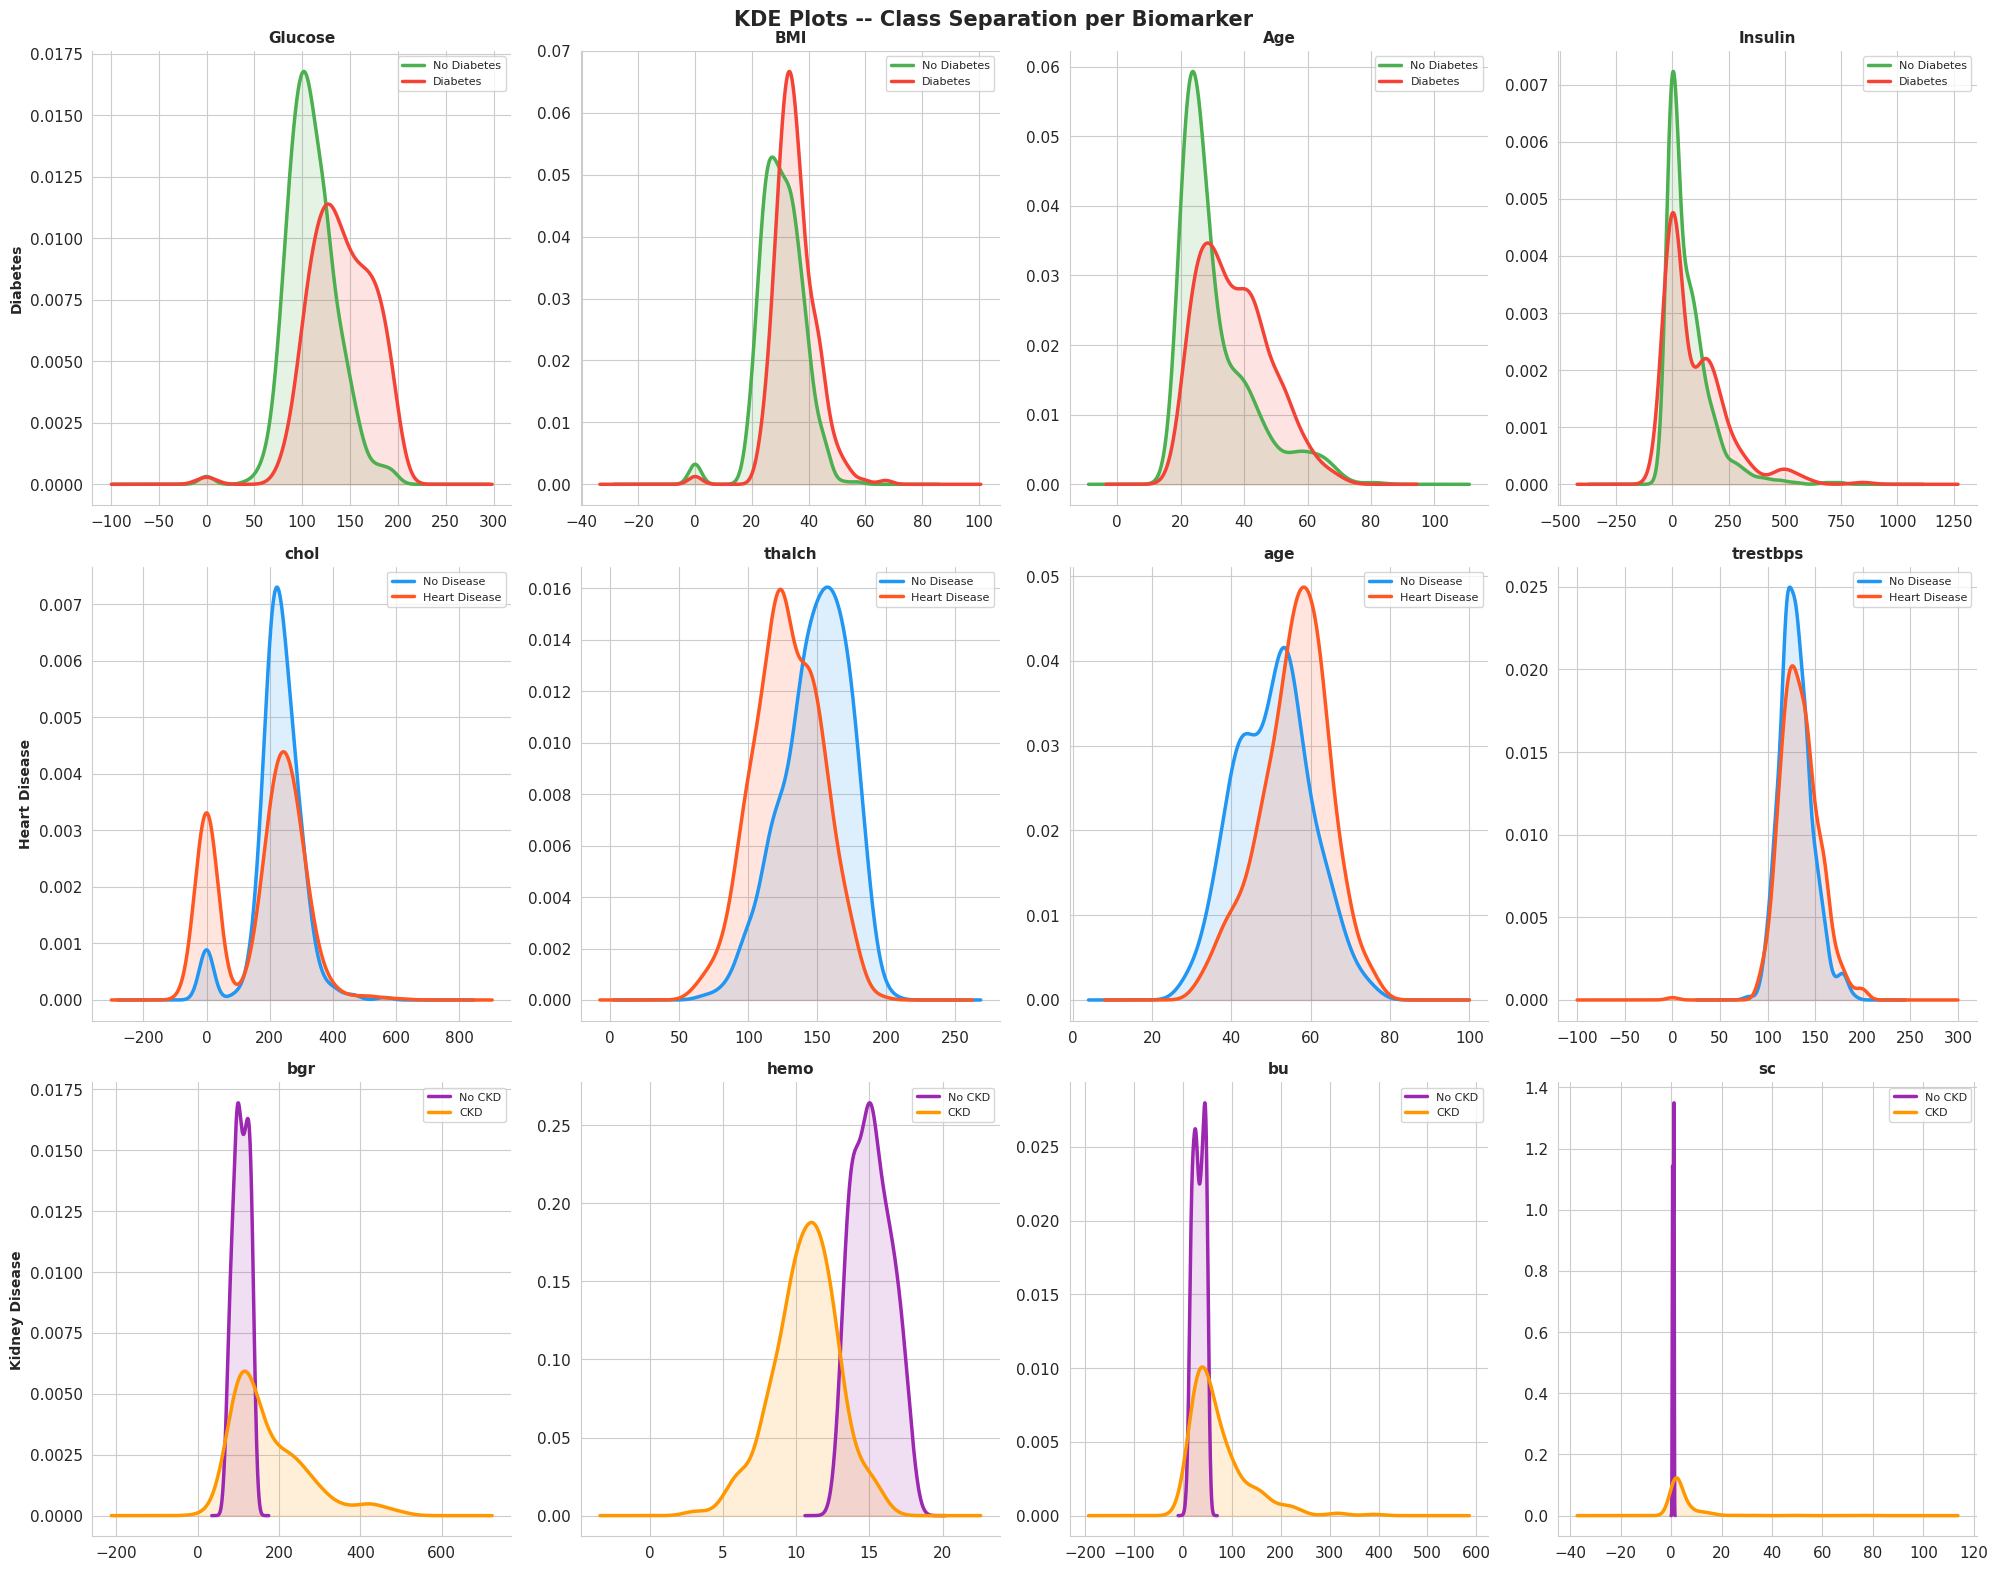

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(20, 16))
fig.suptitle("KDE Plots -- Class Separation per Biomarker", fontsize=15, fontweight='bold')

rows = [
    (df_dia,'Outcome',['Glucose','BMI','Age','Insulin'],
     'No Diabetes','Diabetes','#4CAF50','#F44336','Diabetes'),
    (df_hrt,'target',['chol','thalch','age','trestbps'],
     'No Disease','Heart Disease','#2196F3','#FF5722','Heart Disease'),
    (df_kid,'target_k',['bgr','hemo','bu','sc'],
     'No CKD','CKD','#9C27B0','#FF9800','Kidney Disease'),
]

for r,(df,tcol,feats,lbl0,lbl1,c0,c1,row_label) in enumerate(rows):
    for c, feat in enumerate(feats):
        ax = axes[r][c]
        d0 = pd.to_numeric(df[df[tcol]==0][feat], errors='coerce').dropna()
        d1 = pd.to_numeric(df[df[tcol]==1][feat], errors='coerce').dropna()
        try:
            d0.plot.kde(ax=ax, color=c0, lw=2.5, label=lbl0)
            xs,ys = ax.lines[-1].get_xdata(), ax.lines[-1].get_ydata()
            ax.fill_between(xs, ys, alpha=0.15, color=c0)
        except: pass
        try:
            d1.plot.kde(ax=ax, color=c1, lw=2.5, label=lbl1)
            xs,ys = ax.lines[-1].get_xdata(), ax.lines[-1].get_ydata()
            ax.fill_between(xs, ys, alpha=0.15, color=c1)
        except: pass
        ax.set_title(feat, fontweight='bold', fontsize=11)
        ax.legend(fontsize=8); ax.set_ylabel('')
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        if c == 0: ax.set_ylabel(row_label, fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### 3.6 — Scatter Plots

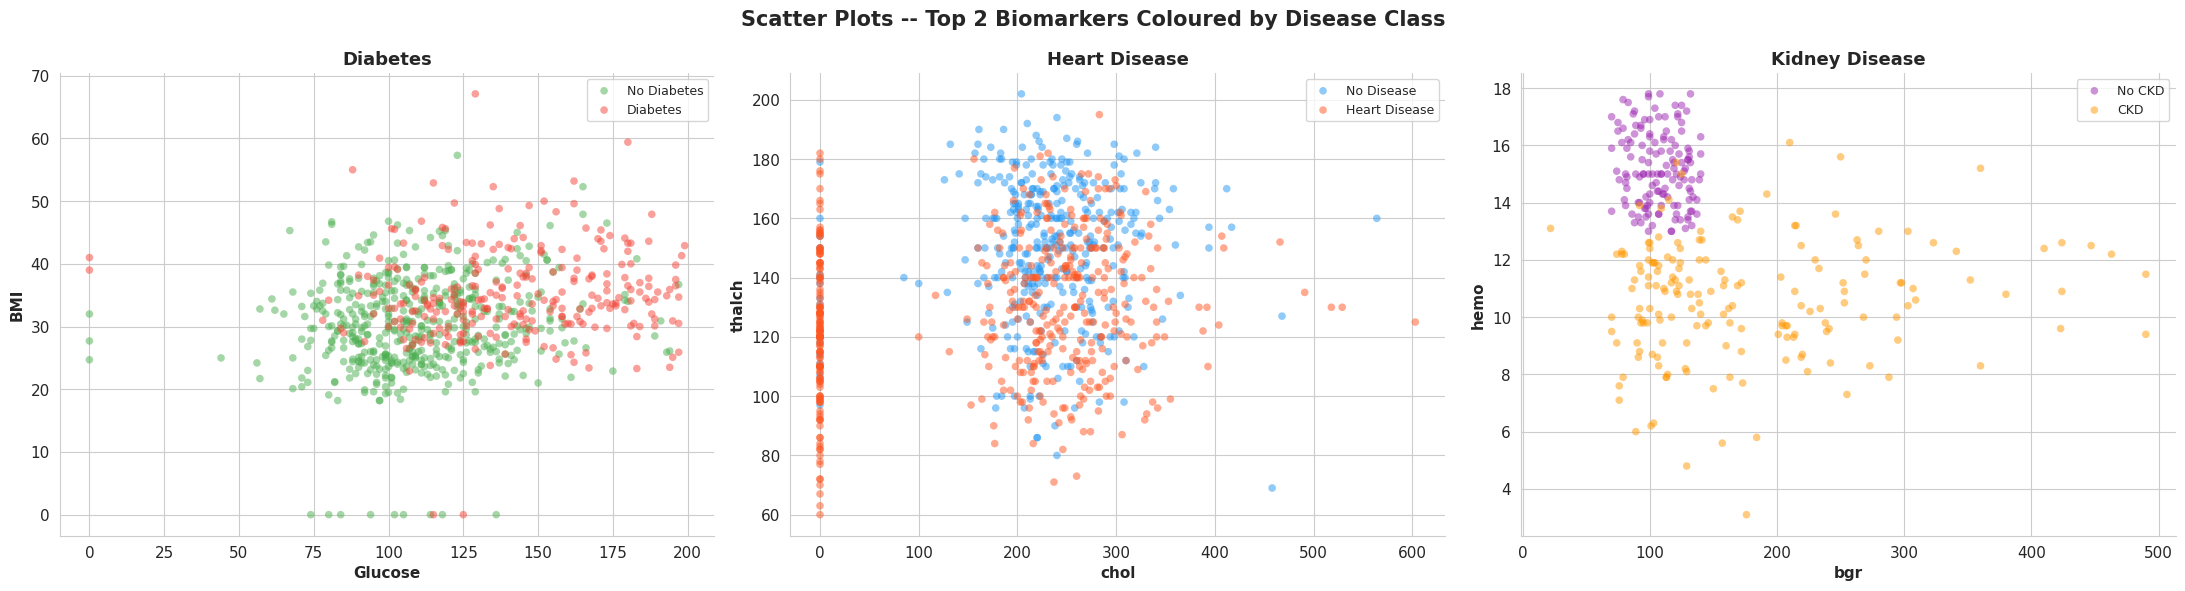

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle("Scatter Plots -- Top 2 Biomarkers Coloured by Disease Class", fontsize=15, fontweight='bold')

cfg = [
    (df_dia,'Outcome','Glucose','BMI',   ['No Diabetes','Diabetes'],     ['#4CAF50','#F44336'],'Diabetes'),
    (df_hrt,'target', 'chol',  'thalch', ['No Disease','Heart Disease'], ['#2196F3','#FF5722'],'Heart Disease'),
    (df_kid,'target_k','bgr',  'hemo',   ['No CKD','CKD'],               ['#9C27B0','#FF9800'],'Kidney Disease'),
]

for ax,(df,tcol,fx,fy,labels,colors,title) in zip(axes,cfg):
    for cls,color,label in zip([0,1],colors,labels):
        sub = df[df[tcol]==cls][[fx,fy]].apply(pd.to_numeric, errors='coerce').dropna()
        ax.scatter(sub[fx], sub[fy], c=color, label=label, alpha=0.5, s=30, edgecolors='none')
    ax.set_xlabel(fx, fontweight='bold'); ax.set_ylabel(fy, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=13); ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 3.7 — Correlation Heatmaps

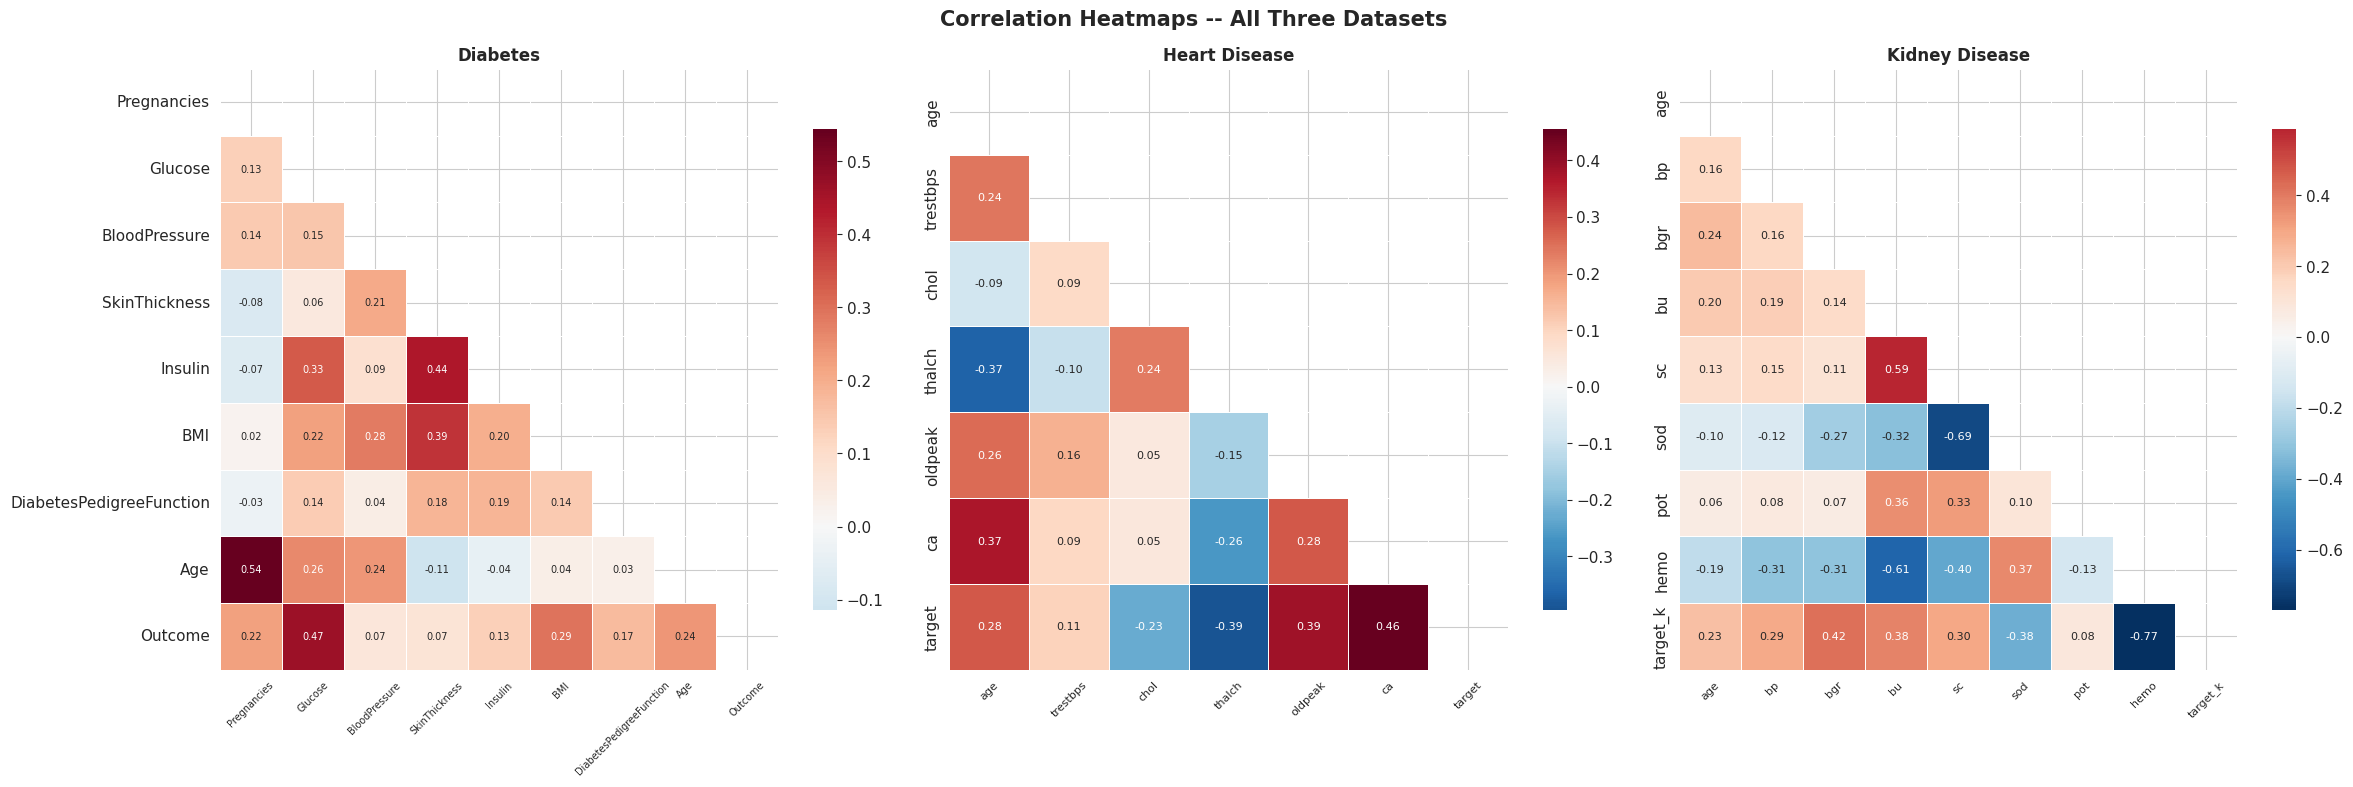

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle("Correlation Heatmaps -- All Three Datasets", fontsize=15, fontweight='bold')

corr_d = df_dia.corr()
sns.heatmap(corr_d, mask=np.triu(np.ones_like(corr_d,dtype=bool)), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5, annot_kws={'size':7}, ax=axes[0], cbar_kws={'shrink':0.8})
axes[0].set_title('Diabetes', fontweight='bold', fontsize=12)
axes[0].tick_params(axis='x', rotation=45, labelsize=7)


num_h = df_hrt[['age','trestbps','chol','thalch','oldpeak','ca','target']].apply(pd.to_numeric, errors='coerce')
corr_h = num_h.corr()
sns.heatmap(corr_h, mask=np.triu(np.ones_like(corr_h,dtype=bool)), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5, annot_kws={'size':8}, ax=axes[1], cbar_kws={'shrink':0.8})
axes[1].set_title('Heart Disease', fontweight='bold', fontsize=12)
axes[1].tick_params(axis='x', rotation=45, labelsize=8)

num_k = df_kid[['age','bp','bgr','bu','sc','sod','pot','hemo','target_k']].apply(pd.to_numeric, errors='coerce')
corr_k = num_k.corr()
sns.heatmap(corr_k, mask=np.triu(np.ones_like(corr_k,dtype=bool)), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5, annot_kws={'size':8}, ax=axes[2], cbar_kws={'shrink':0.8})
axes[2].set_title('Kidney Disease', fontweight='bold', fontsize=12)
axes[2].tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.show()

### 3.8 — Top Feature Correlations with Target

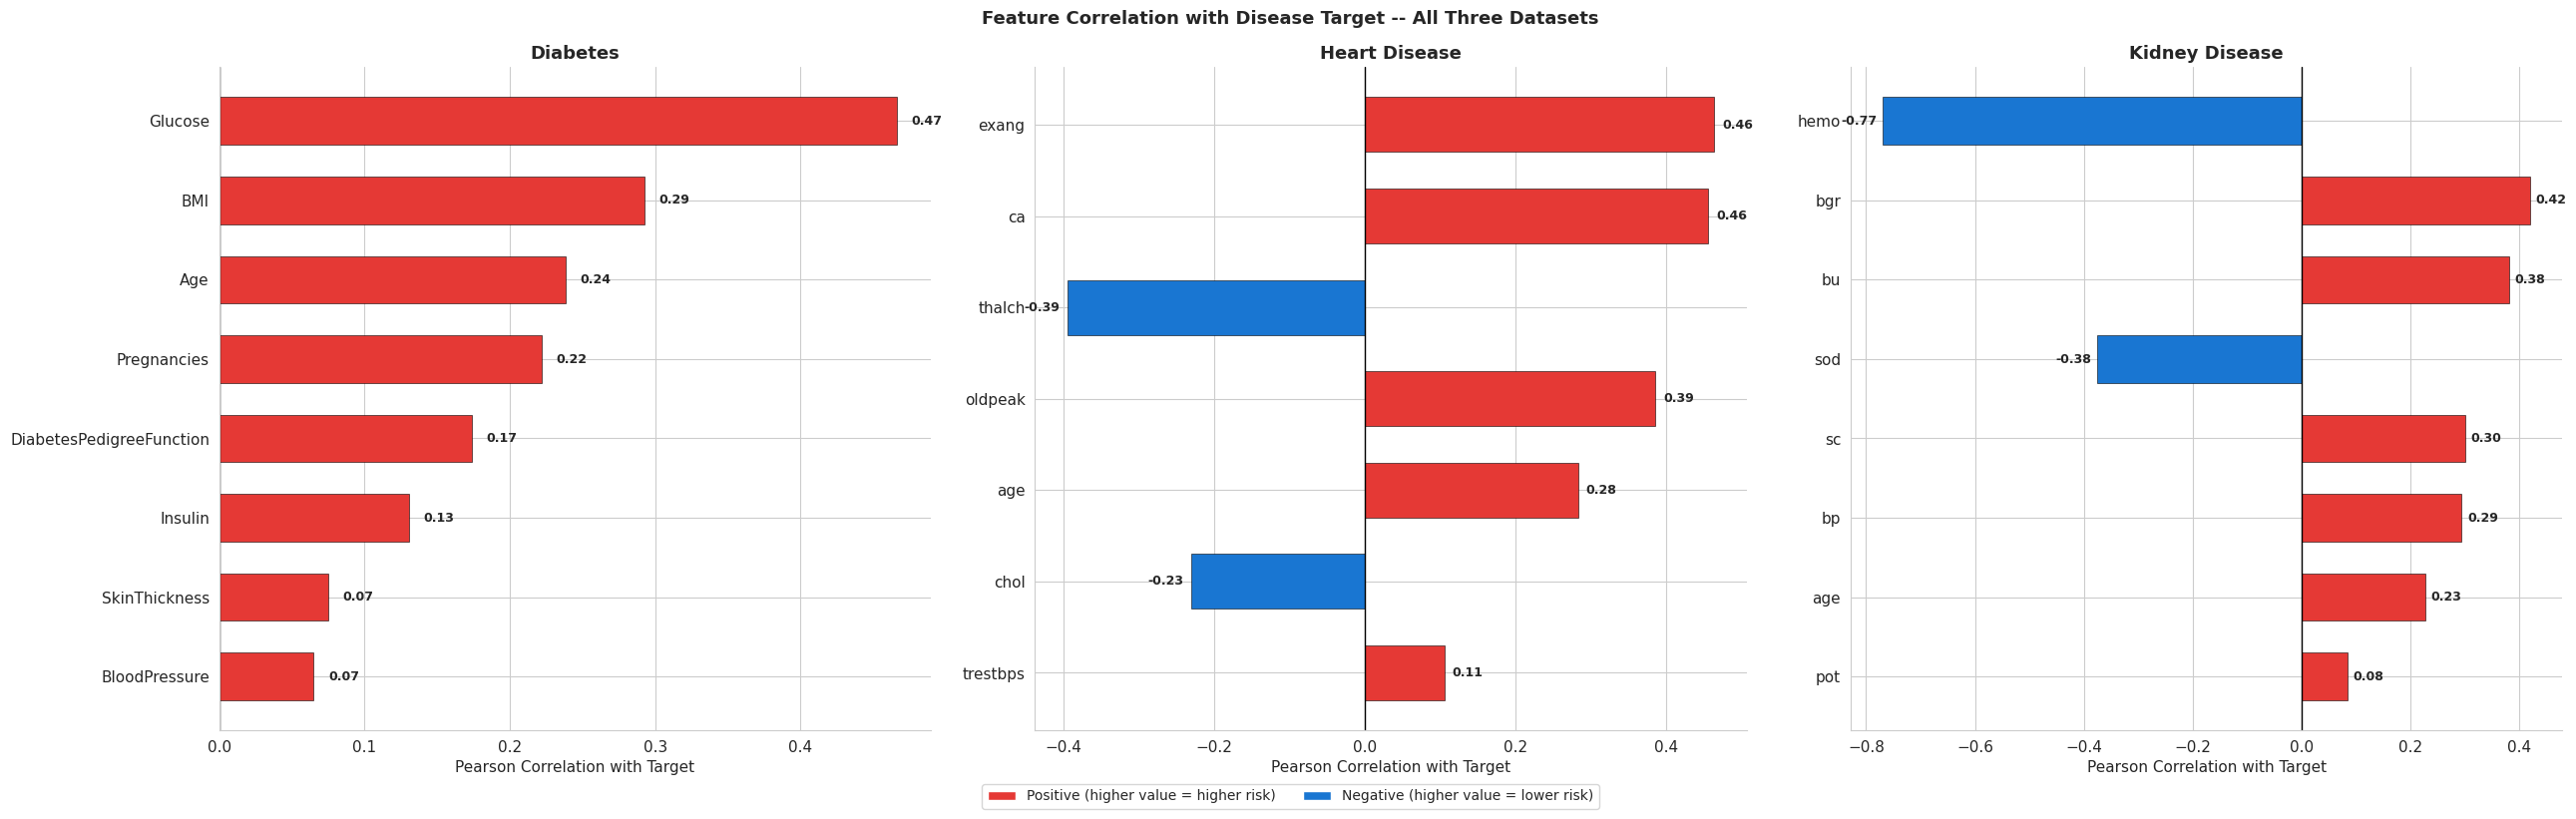

In [ ]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 3, figsize=(26, 8))
fig.suptitle("Feature Correlation with Disease Target -- All Three Datasets", fontsize=13, fontweight='bold')

corr_cfg = [
    (df_dia, 'Outcome', 'Diabetes'),
    (df_hrt[['age','trestbps','chol','thalch','oldpeak','ca','exang','slope','target']].apply(pd.to_numeric,errors='coerce'), 'target', 'Heart Disease'),
    (df_kid[['age','bp','bgr','bu','sc','sod','pot','hemo','target_k']].apply(pd.to_numeric,errors='coerce'), 'target_k', 'Kidney Disease'),
]

for ax,(df,tcol,title) in zip(axes,corr_cfg):
    corr = df.corr()[tcol].drop(tcol).sort_values(key=abs, ascending=True)
    bar_colors = ['#e53935' if v>0 else '#1976d2' for v in corr.values]
    bars = ax.barh(corr.index, corr.values, color=bar_colors, edgecolor='black', linewidth=0.4, height=0.6)
    ax.axvline(0, color='black', linewidth=1)
    for bar, val in zip(bars, corr.values):
        xpos = val+0.01 if val>=0 else val-0.01
        ax.text(xpos, bar.get_y()+bar.get_height()/2, f'{val:.2f}', va='center',
                ha='left' if val>=0 else 'right', fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_xlabel('Pearson Correlation with Target')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.legend(handles=[Patch(facecolor='#e53935',label='Positive (higher value = higher risk)'),
                    Patch(facecolor='#1976d2',label='Negative (higher value = lower risk)')],
           loc='lower center', ncol=2, fontsize=10, bbox_to_anchor=(0.5,-0.03))
plt.tight_layout()
plt.show()

## Step 4 — Data Preprocessing



In [ ]:
# DIABETES
df_d = df_dia.copy()
zero_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df_d[zero_cols] = df_d[zero_cols].replace(0, np.nan)
X_d = df_d.drop('Outcome', axis=1)
y_d = df_d['Outcome']
imp_d    = SimpleImputer(strategy='median')
X_d      = pd.DataFrame(imp_d.fit_transform(X_d), columns=X_d.columns)
scaler_d = StandardScaler()
X_d_sc   = pd.DataFrame(scaler_d.fit_transform(X_d), columns=X_d.columns)
feat_d   = list(X_d.columns)
print("Diabetes preprocessed:", X_d_sc.shape, "| class dist:", y_d.value_counts().to_dict())

Diabetes preprocessed: (768, 8) | class dist: {0: 500, 1: 268}


In [ ]:
# HEART DISEASE
df_h = df_hrt.copy()
df_h = df_h.drop(columns=['id','dataset'], errors='ignore')
df_h = df_h.drop(columns=['num'])
for col in ['fbs','exang']:
    df_h[col] = df_h[col].map({True:1, False:0, 'TRUE':1, 'FALSE':0}).astype(float)
le = LabelEncoder()
for col in ['sex','cp','restecg','slope','thal']:
    df_h[col] = df_h[col].astype(str)
    df_h[col] = le.fit_transform(df_h[col])
X_h = df_h.drop('target', axis=1)
y_h = df_h['target']
imp_h    = SimpleImputer(strategy='median')
X_h      = pd.DataFrame(imp_h.fit_transform(X_h), columns=X_h.columns)
scaler_h = StandardScaler()
X_h_sc   = pd.DataFrame(scaler_h.fit_transform(X_h), columns=X_h.columns)
feat_h   = list(X_h.columns)
print("Heart Disease preprocessed:", X_h_sc.shape, "| class dist:", y_h.value_counts().to_dict())

Heart Disease preprocessed: (920, 13) | class dist: {1: 509, 0: 411}


In [ ]:
# KIDNEY DISEASE
df_k = df_kid.copy()
df_k = df_k.drop(columns=['id'], errors='ignore')

# Strip whitespace/tabs from all string columns (fixes 'ckd\t' hidden tab issue)
for col in df_k.select_dtypes(include='object').columns:
    df_k[col] = df_k[col].str.strip()

# Encode target
df_k['target_k'] = (df_k['classification'] == 'ckd').astype(int)
df_k = df_k.drop(columns=['classification'])

# Map binary categorical columns
binary_map = {'yes':1,'no':0,'normal':1,'abnormal':0,'present':1,'notpresent':0,'good':1,'poor':0}
cat_cols = ['rbc','pc','pcc','ba','htn','dm','cad','appet','pe','ane']
for col in cat_cols:
    df_k[col] = df_k[col].map(binary_map)

# Convert mixed-type numeric columns
for col in ['pcv','wc','rc']:
    df_k[col] = pd.to_numeric(df_k[col], errors='coerce')

X_k = df_k.drop('target_k', axis=1)
y_k = df_k['target_k']
imp_k    = SimpleImputer(strategy='median')
X_k      = pd.DataFrame(imp_k.fit_transform(X_k), columns=X_k.columns)
scaler_k = StandardScaler()
X_k_sc   = pd.DataFrame(scaler_k.fit_transform(X_k), columns=X_k.columns)
feat_k   = list(X_k.columns)
print("Kidney Disease preprocessed:", X_k_sc.shape, "| class dist:", y_k.value_counts().to_dict())

Kidney Disease preprocessed: (400, 24) | class dist: {1: 250, 0: 150}


## Step 5 — Feature Selection (ANOVA F-Score)

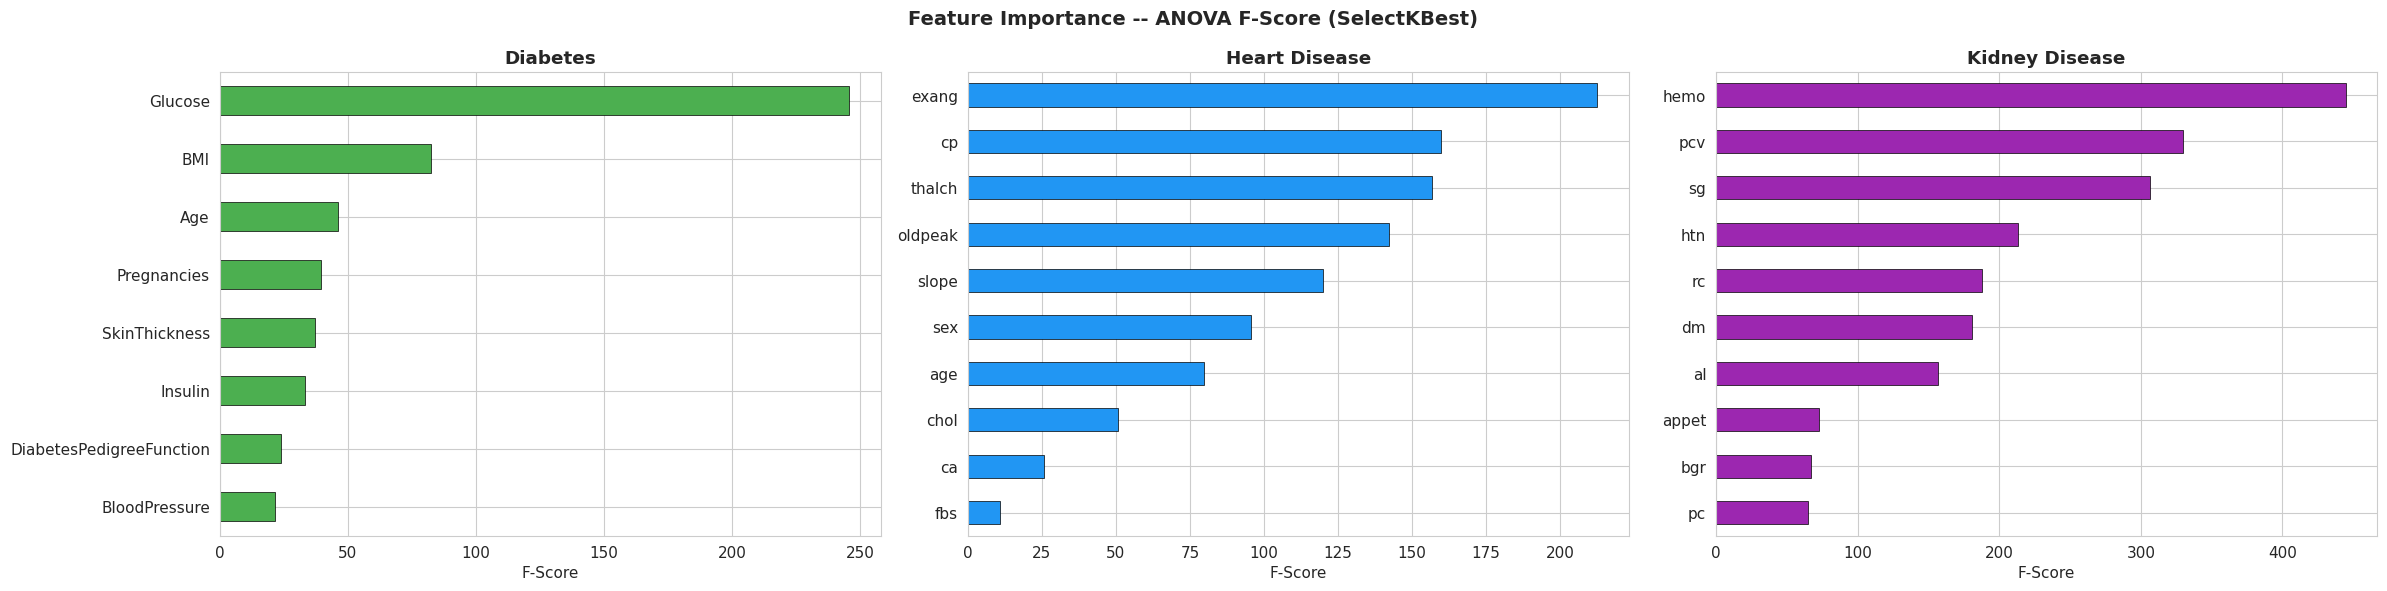

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
fig.suptitle("Feature Importance -- ANOVA F-Score (SelectKBest)", fontsize=14, fontweight='bold')

for ax, (X, y, feats, title, col) in zip(axes, [
    (X_d_sc, y_d, feat_d, 'Diabetes',       '#4CAF50'),
    (X_h_sc, y_h, feat_h, 'Heart Disease',  '#2196F3'),
    (X_k_sc, y_k, feat_k, 'Kidney Disease', '#9C27B0'),
]):
    sel = SelectKBest(score_func=f_classif, k='all')
    sel.fit(X, y)
    top = pd.Series(sel.scores_, index=feats).nlargest(10).sort_values()
    top.plot.barh(ax=ax, color=col, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('F-Score')

plt.tight_layout()
plt.show()

## Step 6 — Train / Test Split (80/20 Stratified) + SMOTE


In [ ]:
# Splitting first on original  scaled data
Xtr_d_raw, Xte_d, ytr_d_raw, yte_d = train_test_split(X_d_sc, y_d, test_size=0.2, random_state=42, stratify=y_d)
Xtr_h_raw, Xte_h, ytr_h_raw, yte_h = train_test_split(X_h_sc, y_h, test_size=0.2, random_state=42, stratify=y_h)
Xtr_k_raw, Xte_k, ytr_k_raw, yte_k = train_test_split(X_k_sc, y_k, test_size=0.2, random_state=42, stratify=y_k)

#Applying SMOTE only on training sets
sm = SMOTE(random_state=42)
Xtr_d, ytr_d = sm.fit_resample(Xtr_d_raw, ytr_d_raw)
Xtr_h, ytr_h = sm.fit_resample(Xtr_h_raw, ytr_h_raw)
Xtr_k, ytr_k = sm.fit_resample(Xtr_k_raw, ytr_k_raw)

print("Train/Test sizes (after SMOTE on train only):")
print(f"Diabetes       Train: {Xtr_d.shape[0]}  Test (original): {Xte_d.shape[0]}")
print(f"Heart Disease  Train: {Xtr_h.shape[0]}  Test (original): {Xte_h.shape[0]}")
print(f"Kidney Disease Train: {Xtr_k.shape[0]}  Test (original): {Xte_k.shape[0]}")

print("\nClass distribution after SMOTE (training only):")
print(f"  Diabetes       : {dict(zip(*np.unique(ytr_d, return_counts=True)))}")
print(f"  Heart Disease  : {dict(zip(*np.unique(ytr_h, return_counts=True)))}")
print(f"  Kidney Disease : {dict(zip(*np.unique(ytr_k, return_counts=True)))}")

Train/Test sizes (after SMOTE on train only):
Diabetes       Train: 800  Test (original): 154
Heart Disease  Train: 814  Test (original): 184
Kidney Disease Train: 400  Test (original): 80

Class distribution after SMOTE (training only):
  Diabetes       : {np.int64(0): np.int64(400), np.int64(1): np.int64(400)}
  Heart Disease  : {np.int64(0): np.int64(407), np.int64(1): np.int64(407)}
  Kidney Disease : {np.int64(0): np.int64(200), np.int64(1): np.int64(200)}


## Step 7 — Model Training & Evaluation

In [ ]:
MODELS = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'                 : SVC(probability=True, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

def train_eval(Xtr, ytr, Xte, yte, label=""):
    results = {}
    for name, model in MODELS.items():
        m = copy.deepcopy(model)
        m.fit(Xtr, ytr)
        yp    = m.predict(Xte)
        yprob = m.predict_proba(Xte)[:,1]
        acc   = accuracy_score(yte, yp)
        prec  = precision_score(yte, yp, zero_division=0)
        rec   = recall_score(yte, yp, zero_division=0)
        f1    = f1_score(yte, yp, zero_division=0)
        auc   = roc_auc_score(yte, yprob)
        results[name] = [m, acc, prec, rec, f1, auc, yprob]
        print(f"  [{label}] {name:22s}  Acc={acc:.4f}  F1={f1:.4f}  Recall={rec:.4f}  AUC={auc:.4f}")
    return results

print("Training models on all three datasets...\n")
tr_d = train_eval(Xtr_d, ytr_d, Xte_d, yte_d, "Diabetes")
print()
tr_h = train_eval(Xtr_h, ytr_h, Xte_h, yte_h, "Heart")
print()
tr_k = train_eval(Xtr_k, ytr_k, Xte_k, yte_k, "Kidney")
print("\nAll models trained.")

Training models on all three datasets...

  [Diabetes] Logistic Regression     Acc=0.7208  F1=0.6325  Recall=0.6852  AUC=0.8109
  [Diabetes] Random Forest           Acc=0.7338  F1=0.6496  Recall=0.7037  AUC=0.8187
  [Diabetes] SVM                     Acc=0.7273  F1=0.6379  Recall=0.6852  AUC=0.8098
  [Diabetes] Gradient Boosting       Acc=0.7468  F1=0.6723  Recall=0.7407  AUC=0.8226

  [Heart] Logistic Regression     Acc=0.8261  F1=0.8416  Recall=0.8333  AUC=0.8837
  [Heart] Random Forest           Acc=0.8370  F1=0.8544  Recall=0.8627  AUC=0.9145
  [Heart] SVM                     Acc=0.8478  F1=0.8641  Recall=0.8725  AUC=0.9159
  [Heart] Gradient Boosting       Acc=0.8370  F1=0.8571  Recall=0.8824  AUC=0.9125

  [Kidney] Logistic Regression     Acc=0.9750  F1=0.9796  Recall=0.9600  AUC=1.0000
  [Kidney] Random Forest           Acc=1.0000  F1=1.0000  Recall=1.0000  AUC=1.0000
  [Kidney] SVM                     Acc=1.0000  F1=1.0000  Recall=1.0000  AUC=1.0000
  [Kidney] Gradient Boosting

## Step 8 — Hyperparameter Tuning (GridSearchCV)

In [ ]:
param_rf = {'n_estimators':[100,200], 'max_depth':[None,10,20], 'min_samples_split':[2,5]}

print("Tuning Random Forest...")
best_rf = {}
for ds, (Xtr, ytr) in [('Diabetes',(Xtr_d,ytr_d)),('Heart Disease',(Xtr_h,ytr_h)),('Kidney Disease',(Xtr_k,ytr_k))]:
    gs = GridSearchCV(RandomForestClassifier(random_state=42), param_rf, cv=5, scoring='f1', n_jobs=-1)
    gs.fit(Xtr, ytr)
    best_rf[ds] = gs.best_estimator_
    print(f"  {ds:15s}: {gs.best_params_}  CV F1={gs.best_score_:.4f}")

Tuning Random Forest...
  Diabetes       : {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}  CV F1=0.8445
  Heart Disease  : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}  CV F1=0.8352
  Kidney Disease : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}  CV F1=0.9925


In [ ]:
param_gb = {'n_estimators':[100,200], 'learning_rate':[0.05,0.1], 'max_depth':[3,5]}

print("Tuning Gradient Boosting...")
best_gb = {}
for ds, (Xtr, ytr) in [('Diabetes',(Xtr_d,ytr_d)),('Heart Disease',(Xtr_h,ytr_h)),('Kidney Disease',(Xtr_k,ytr_k))]:
    gs = GridSearchCV(GradientBoostingClassifier(random_state=42), param_gb, cv=5, scoring='f1', n_jobs=-1)
    gs.fit(Xtr, ytr)
    best_gb[ds] = gs.best_estimator_
    print(f"  {ds:15s}: {gs.best_params_}  CV F1={gs.best_score_:.4f}")

print("\nTuning complete.")

Tuning Gradient Boosting...
  Diabetes       : {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}  CV F1=0.8128
  Heart Disease  : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}  CV F1=0.8244
  Kidney Disease : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}  CV F1=0.9925

Tuning complete.


In [ ]:
def eval_tuned(model, Xte, yte, ds, mname):
    yp    = model.predict(Xte)
    yprob = model.predict_proba(Xte)[:,1]
    acc   = accuracy_score(yte, yp)
    prec  = precision_score(yte, yp, zero_division=0)
    rec   = recall_score(yte, yp, zero_division=0)
    f1    = f1_score(yte, yp, zero_division=0)
    auc   = roc_auc_score(yte, yprob)
    print(f"  [{ds}] Tuned {mname:22s}  Acc={acc:.4f}  F1={f1:.4f}  Recall={rec:.4f}  AUC={auc:.4f}")
    return [model, acc, prec, rec, f1, auc, yprob]

print("Tuned Random Forest results on test set:")
tuned_rf_d = eval_tuned(best_rf['Diabetes'],       Xte_d, yte_d, 'Diabetes',       'Random Forest')
tuned_rf_h = eval_tuned(best_rf['Heart Disease'],  Xte_h, yte_h, 'Heart Disease',  'Random Forest')
tuned_rf_k = eval_tuned(best_rf['Kidney Disease'], Xte_k, yte_k, 'Kidney Disease', 'Random Forest')

print("\nTuned Gradient Boosting results on test set:")
tuned_gb_d = eval_tuned(best_gb['Diabetes'],       Xte_d, yte_d, 'Diabetes',       'Gradient Boosting')
tuned_gb_h = eval_tuned(best_gb['Heart Disease'],  Xte_h, yte_h, 'Heart Disease',  'Gradient Boosting')
tuned_gb_k = eval_tuned(best_gb['Kidney Disease'], Xte_k, yte_k, 'Kidney Disease', 'Gradient Boosting')

Tuned Random Forest results on test set:
  [Diabetes] Tuned Random Forest           Acc=0.7532  F1=0.6724  Recall=0.7222  AUC=0.8148
  [Heart Disease] Tuned Random Forest           Acc=0.8370  F1=0.8544  Recall=0.8627  AUC=0.9145
  [Kidney Disease] Tuned Random Forest           Acc=1.0000  F1=1.0000  Recall=1.0000  AUC=1.0000

Tuned Gradient Boosting results on test set:
  [Diabetes] Tuned Gradient Boosting       Acc=0.7403  F1=0.6429  Recall=0.6667  AUC=0.8180
  [Heart Disease] Tuned Gradient Boosting       Acc=0.8370  F1=0.8544  Recall=0.8627  AUC=0.9010
  [Kidney Disease] Tuned Gradient Boosting       Acc=1.0000  F1=1.0000  Recall=1.0000  AUC=1.0000


## Step 9 — Results & Evaluation

### 9.1 Performance Tables

In [ ]:
cols = ['Model','Accuracy','Precision','Recall','F1','AUC']

def make_table(tr, tuned_rf, tuned_gb):
    rows = [[k]+[round(v,4) for v in vals[1:6]] for k,vals in tr.items()]
    rows.append(['Tuned Random Forest']    + [round(v,4) for v in tuned_rf[1:6]])
    rows.append(['Tuned Gradient Boosting']+ [round(v,4) for v in tuned_gb[1:6]])
    return pd.DataFrame(rows, columns=cols)

res_d = make_table(tr_d, tuned_rf_d, tuned_gb_d)
res_h = make_table(tr_h, tuned_rf_h, tuned_gb_h)
res_k = make_table(tr_k, tuned_rf_k, tuned_gb_k)

for name, res in [('Diabetes', res_d), ('Heart Disease', res_h), ('Kidney Disease', res_k)]:
    print(f"\n-- {name} --")
    display(res.set_index('Model').style.background_gradient(
        subset=['Accuracy','F1','AUC','Recall'], cmap='RdYlGn').format('{:.4f}'))


-- Diabetes --


,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Logistic Regression,0.7208,0.5873,0.6852,0.6325,0.8109
Random Forest,0.7338,0.6032,0.7037,0.6496,0.8187
SVM,0.7273,0.5968,0.6852,0.6379,0.8098
Gradient Boosting,0.7468,0.6154,0.7407,0.6723,0.8226
Tuned Random Forest,0.7532,0.6290,0.7222,0.6724,0.8148
Tuned Gradient Boosting,0.7403,0.6207,0.6667,0.6429,0.8180



-- Heart Disease --


,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Logistic Regression,0.8261,0.8500,0.8333,0.8416,0.8837
Random Forest,0.8370,0.8462,0.8627,0.8544,0.9145
SVM,0.8478,0.8558,0.8725,0.8641,0.9159
Gradient Boosting,0.8370,0.8333,0.8824,0.8571,0.9125
Tuned Random Forest,0.8370,0.8462,0.8627,0.8544,0.9145
Tuned Gradient Boosting,0.8370,0.8462,0.8627,0.8544,0.9010



-- Kidney Disease --


,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Logistic Regression,0.9750,1.0000,0.9600,0.9796,1.0000
Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
SVM,1.0000,1.0000,1.0000,1.0000,1.0000
Gradient Boosting,1.0000,1.0000,1.0000,1.0000,1.0000
Tuned Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
Tuned Gradient Boosting,1.0000,1.0000,1.0000,1.0000,1.0000


### 9.2 F1-Score Comparison

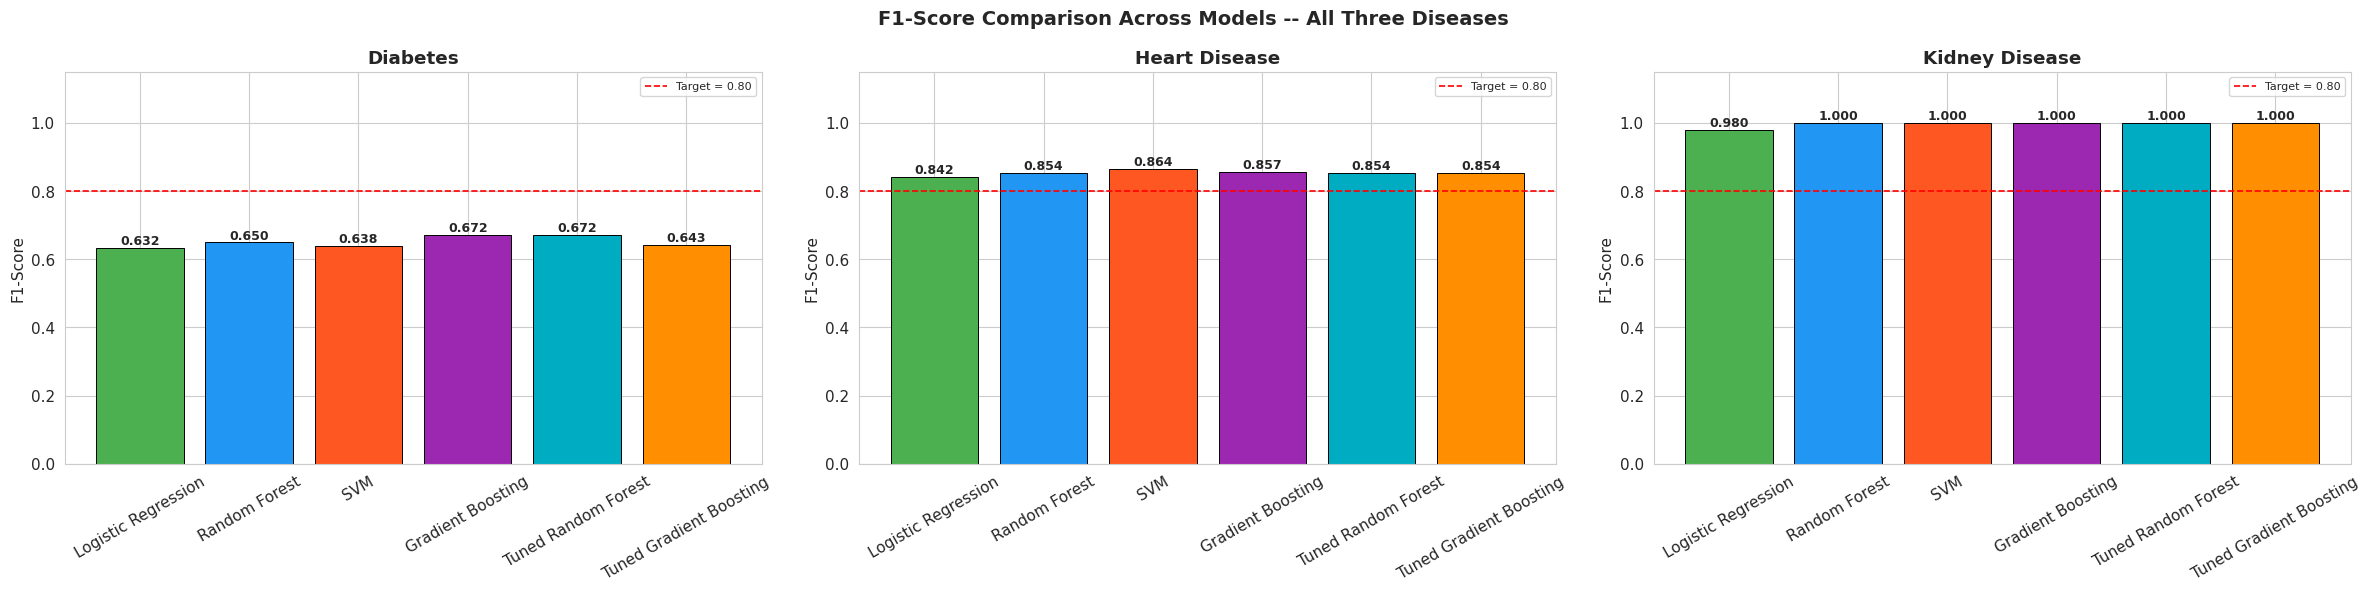

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
fig.suptitle("F1-Score Comparison Across Models -- All Three Diseases", fontsize=14, fontweight='bold')
bar_colors = ['#4CAF50','#2196F3','#FF5722','#9C27B0','#00ACC1','#FF8F00']

for ax, (name, res) in zip(axes, [('Diabetes',res_d),('Heart Disease',res_h),('Kidney Disease',res_k)]):
    bars = ax.bar(res['Model'], res['F1'], color=bar_colors[:len(res)], edgecolor='black', linewidth=0.7)
    ax.axhline(0.80, ls='--', color='red', linewidth=1.2, label='Target = 0.80')
    ax.set_ylim(0, 1.15)
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('F1-Score')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)
    for b, v in zip(bars, res['F1']):
        ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### 9.3 Confusion Matrices

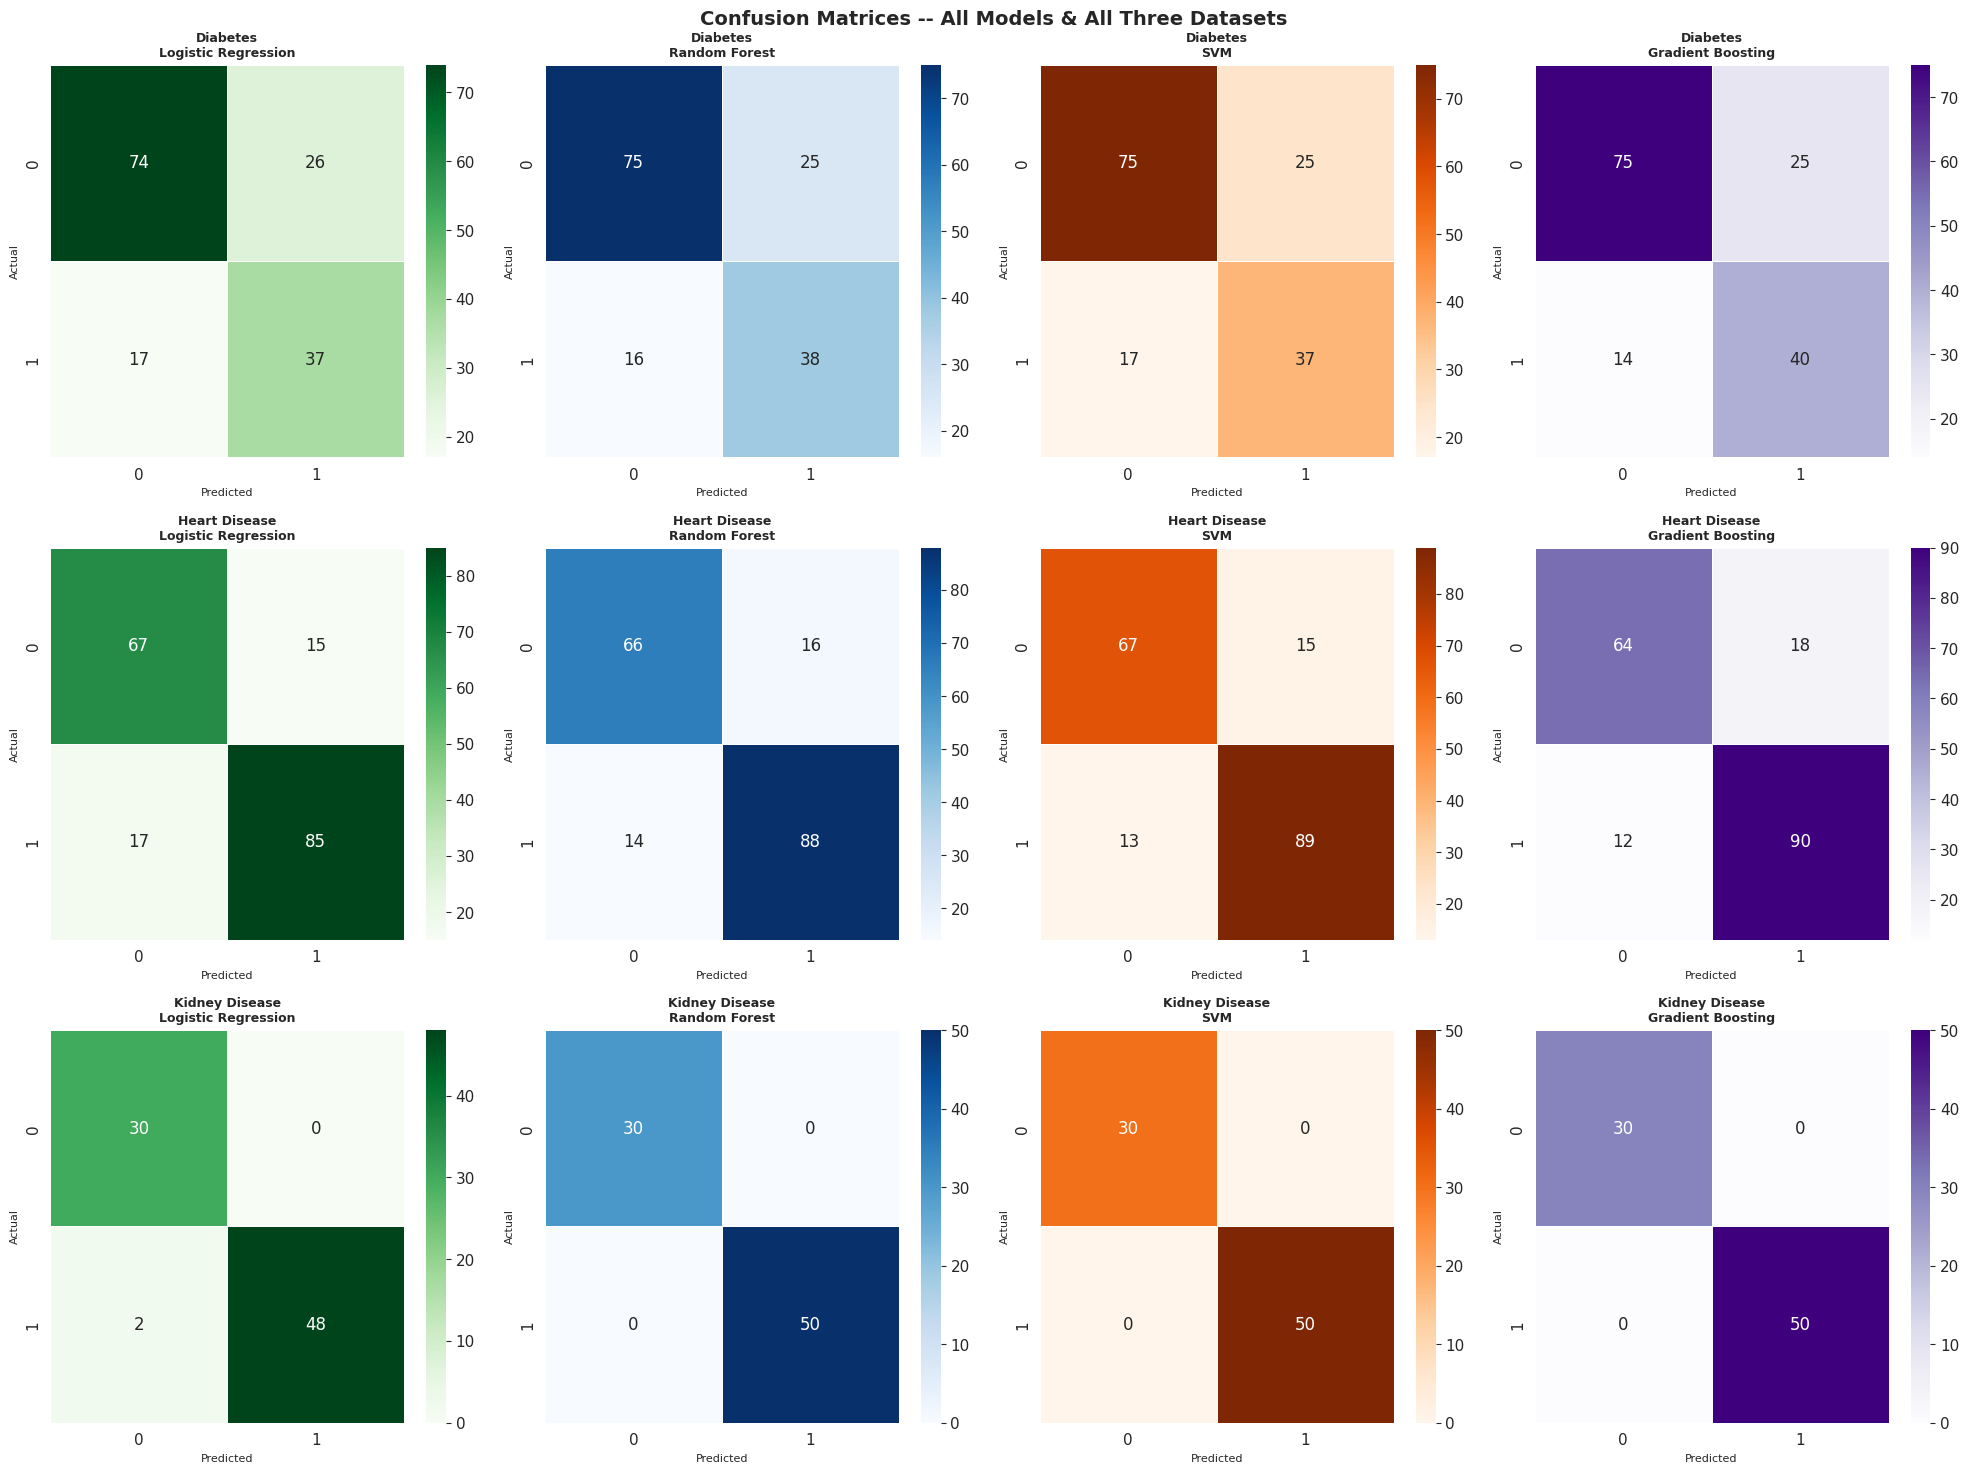

In [ ]:
ds_list = [
    ('Diabetes',       tr_d, Xte_d, yte_d),
    ('Heart Disease',  tr_h, Xte_h, yte_h),
    ('Kidney Disease', tr_k, Xte_k, yte_k),
]

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
fig.suptitle("Confusion Matrices -- All Models & All Three Datasets", fontsize=14, fontweight='bold')
cmaps = ['Greens', 'Blues', 'Oranges', 'Purples']

for row, (ds, trained, Xte, yte) in enumerate(ds_list):
    for col, (mname, metrics) in enumerate(trained.items()):
        ax = axes[row][col]
        ypred = metrics[0].predict(Xte)
        cm = confusion_matrix(yte, ypred)
        sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap=cmaps[col], linewidths=0.5, annot_kws={'size':12})
        ax.set_title(f'{ds}\n{mname}', fontsize=9, fontweight='bold')
        ax.set_xlabel('Predicted', fontsize=8); ax.set_ylabel('Actual', fontsize=8)

plt.tight_layout()
plt.show()

### 9.4 ROC Curves

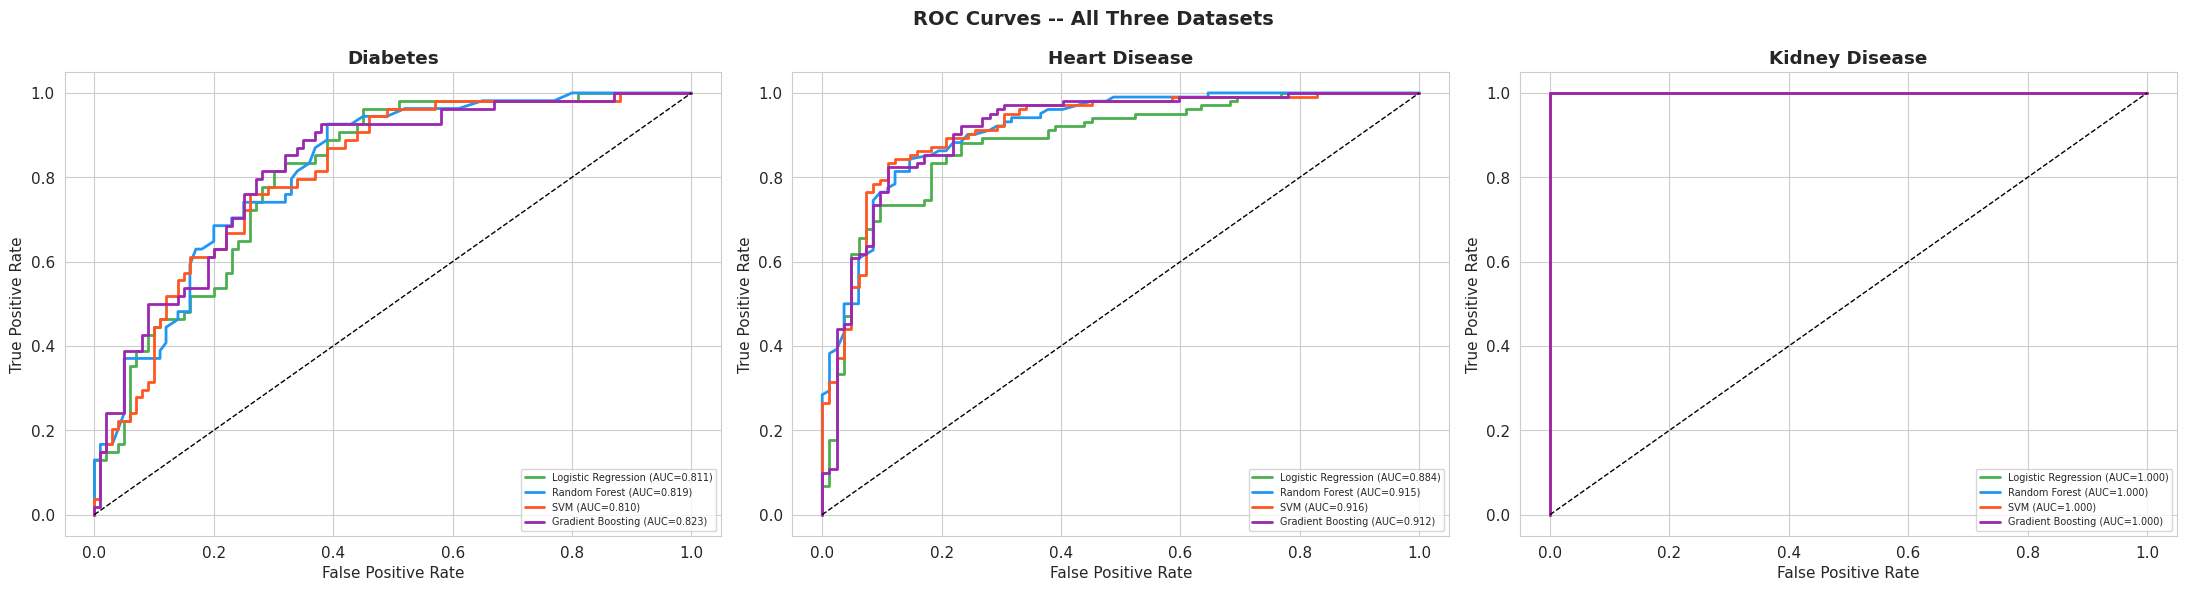

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle("ROC Curves -- All Three Datasets", fontsize=14, fontweight='bold')
lc = ['#4CAF50','#2196F3','#FF5722','#9C27B0']

for ax, (ds, trained, Xte, yte) in zip(axes, ds_list):
    for (mname, metrics_list), c in zip(trained.items(), lc):
        yprob = metrics_list[0].predict_proba(Xte)[:,1]
        fpr, tpr, _ = roc_curve(yte, yprob)
        auc = roc_auc_score(yte, yprob)
        ax.plot(fpr, tpr, color=c, linewidth=2, label=f'{mname} (AUC={auc:.3f})')
    ax.plot([0,1],[0,1],'k--',linewidth=1)
    ax.set_title(ds, fontweight='bold')
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.show()

### 9.5 Cross-Validation F1 Distribution

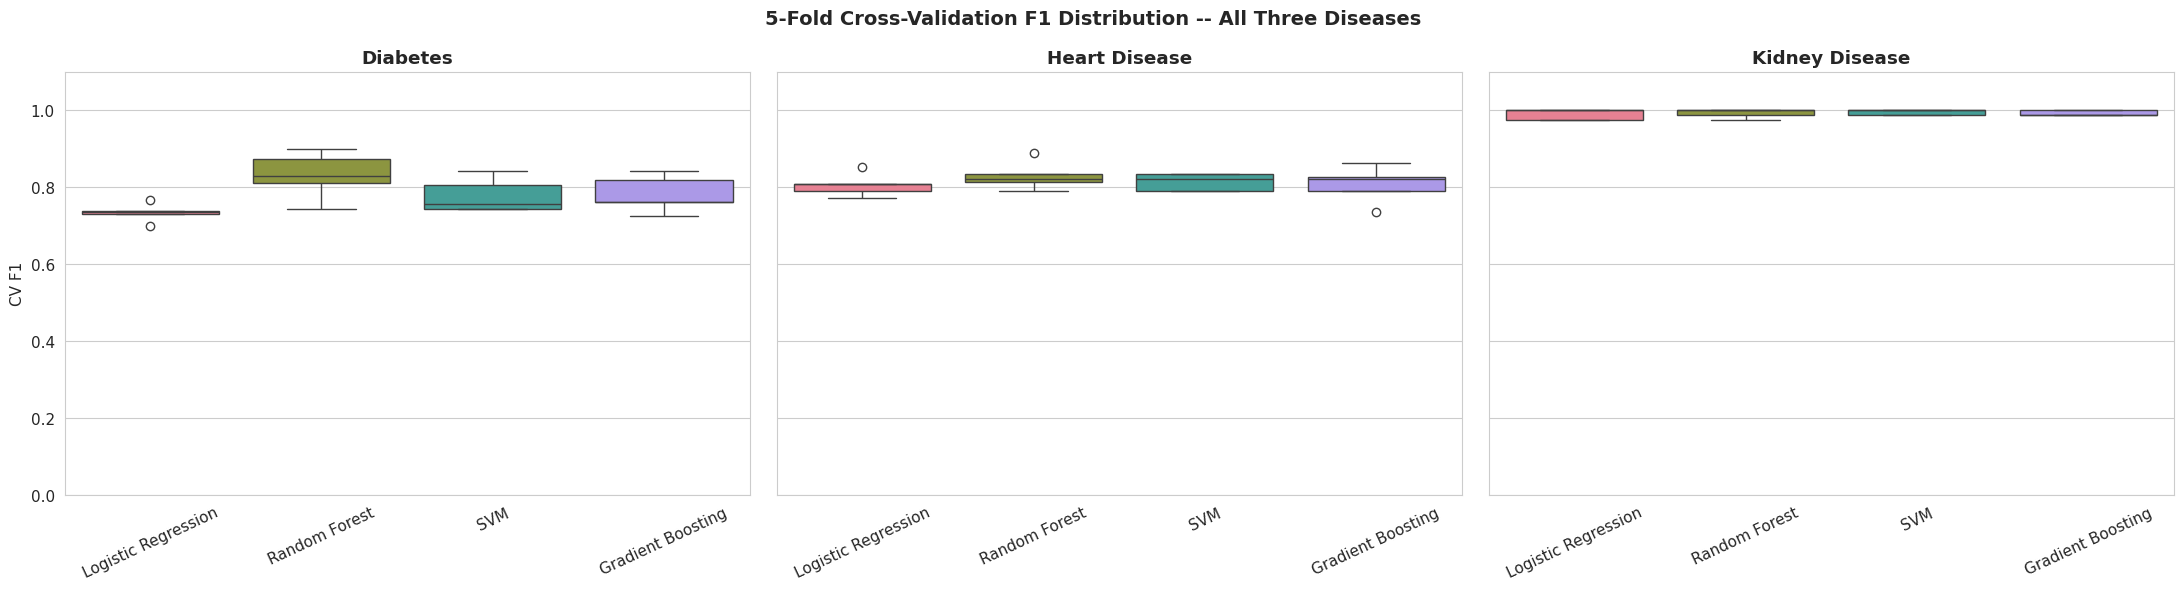

In [ ]:
cv_rec = []
for ds, (Xtr, ytr) in [('Diabetes',(Xtr_d,ytr_d)),('Heart Disease',(Xtr_h,ytr_h)),('Kidney Disease',(Xtr_k,ytr_k))]:
    for mname, model in MODELS.items():
        for s in cross_val_score(model, Xtr, ytr, cv=5, scoring='f1_weighted'):
            cv_rec.append({'Dataset': ds, 'Model': mname, 'CV F1': s})

cv_df = pd.DataFrame(cv_rec)

fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=True)
fig.suptitle("5-Fold Cross-Validation F1 Distribution -- All Three Diseases", fontsize=14, fontweight='bold')
for ax, (ds, grp) in zip(axes, cv_df.groupby('Dataset')):
    sns.boxplot(data=grp, x='Model', y='CV F1', ax=ax, palette='husl')
    ax.set_title(ds, fontweight='bold'); ax.set_ylim(0, 1.1); ax.tick_params(axis='x', rotation=25); ax.set_xlabel('')

plt.tight_layout()
plt.show()

### 9.6 Best Model Summary



In [ ]:

diabetes_results = res_d.assign(Dataset='Diabetes')
heart_results = res_h.assign(Dataset='Heart Disease')
kidney_results = res_k.assign(Dataset='Kidney Disease')

all_results = pd.concat(
    [diabetes_results, heart_results, kidney_results],
    ignore_index=True
)

all_results['F1_Recall_Score'] = (
    all_results['F1'] + all_results['Recall']) / 2

best_models = (
    all_results
    .sort_values(by='F1_Recall_Score', ascending=False)
    .groupby('Dataset')
    .head(1)
    .reset_index(drop=True)
)

best_models = best_models[
    ['Dataset', 'Model', 'F1', 'Recall', 'AUC', 'Accuracy', 'F1_Recall_Score']
]

metrics = ['F1', 'Recall', 'AUC', 'Accuracy', 'F1_Recall_Score']
best_models[metrics] = best_models[metrics].round(3)

best_models = best_models.sort_values(by='Dataset').reset_index(drop=True)

print("Best Model Per Disease (based on combined F1 and Recall):")
display(best_models)

best_models.to_csv("best_model_summary.csv", index=False)

Best Model Per Disease (based on combined F1 and Recall):


,Dataset,Model,F1,Recall,AUC,Accuracy,F1_Recall_Score
0,Diabetes,Gradient Boosting,0.672,0.741,0.823,0.747,0.706
1,Heart Disease,Gradient Boosting,0.857,0.882,0.912,0.837,0.870
2,Kidney Disease,Gradient Boosting,1.000,1.000,1.000,1.000,1.000


### 9.6 Detailed Classification Reports

In [ ]:
# Mapping model names to the correct trained model objects
def get_model_obj(ds, mname, tr_base):
    """Return the correct model object (tuned if available, else base)"""
    if mname == 'Tuned Gradient Boosting':
        return best_gb[ds]
    elif mname == 'Tuned Random Forest':
        return best_rf[ds]
    else:
        return tr_base[mname][0]

neg = {'Diabetes':'No Diabetes','Heart Disease':'No Disease','Kidney Disease':'No CKD'}
pos = {'Diabetes':'Diabetic','Heart Disease':'Heart Disease','Kidney Disease':'CKD'}

for ds, trained, Xte, yte in [('Diabetes',tr_d,Xte_d,yte_d),('Heart Disease',tr_h,Xte_h,yte_h),('Kidney Disease',tr_k,Xte_k,yte_k)]:
    bname = best_summary[best_summary['Dataset']==ds]['Model'].values[0]
    model_obj = get_model_obj(ds, bname, trained)
    ypred = model_obj.predict(Xte)
    print(f"\n-- {ds} | Best model: {bname} --")
    print(classification_report(yte, ypred, target_names=[neg[ds], pos[ds]]))


-- Diabetes | Best model: Gradient Boosting --
              precision    recall  f1-score   support

 No Diabetes       0.84      0.75      0.79       100
    Diabetic       0.62      0.74      0.67        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.76      0.75      0.75       154


-- Heart Disease | Best model: Gradient Boosting --
               precision    recall  f1-score   support

   No Disease       0.84      0.78      0.81        82
Heart Disease       0.83      0.88      0.86       102

     accuracy                           0.84       184
    macro avg       0.84      0.83      0.83       184
 weighted avg       0.84      0.84      0.84       184


-- Kidney Disease | Best model: Random Forest --
              precision    recall  f1-score   support

      No CKD       1.00      1.00      1.00        30
         CKD       1.00      1.00      1.00        50

    accuracy             

## Step 10 — Explainable AI (SHAP)

In [ ]:
import shap, gc
gc.collect(); plt.close("all")

### 10.1 — SHAP: Diabetes

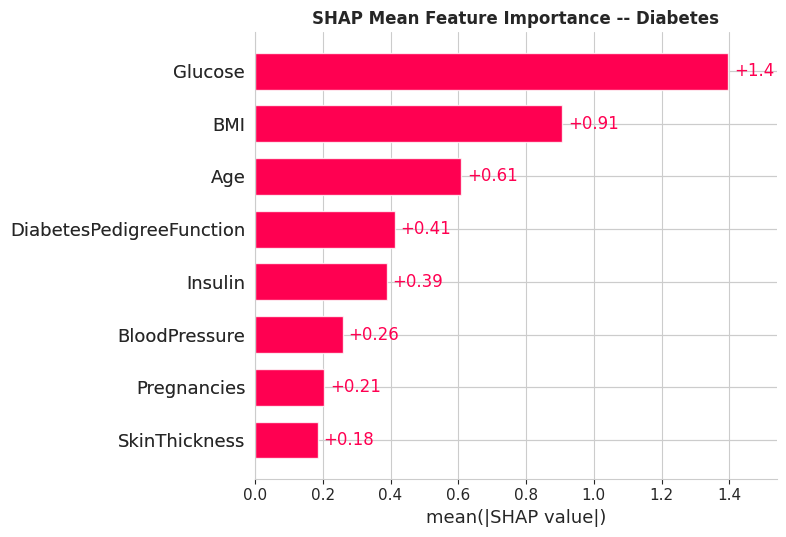

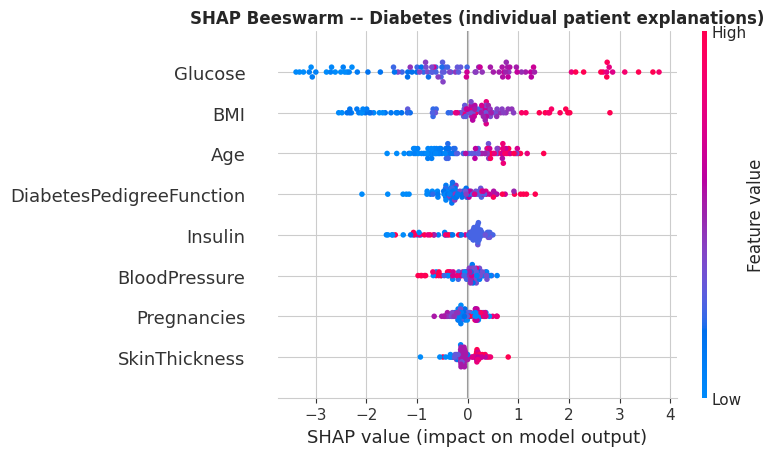

In [ ]:
gc.collect(); plt.close("all")
model_s = best_gb['Diabetes']   # Usiing tuned model for SHAP
explainer = shap.TreeExplainer(model_s)
sv = explainer.shap_values(Xte_d.iloc[:100].reset_index(drop=True))
if isinstance(sv, list): sv = sv[1]
shap_exp = shap.Explanation(values=sv, data=Xte_d.iloc[:100].reset_index(drop=True).values, feature_names=feat_d)

plt.figure()
shap.plots.bar(shap_exp, show=False)
plt.title("SHAP Mean Feature Importance -- Diabetes", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

plt.figure()
shap.plots.beeswarm(shap_exp, show=False)
plt.title("SHAP Beeswarm -- Diabetes (individual patient explanations)", fontweight="bold", fontsize=12)
plt.tight_layout();
plt.show()

del model_s, explainer, sv, shap_exp
gc.collect(); plt.close("all")

### 10.2 — SHAP: Heart Disease

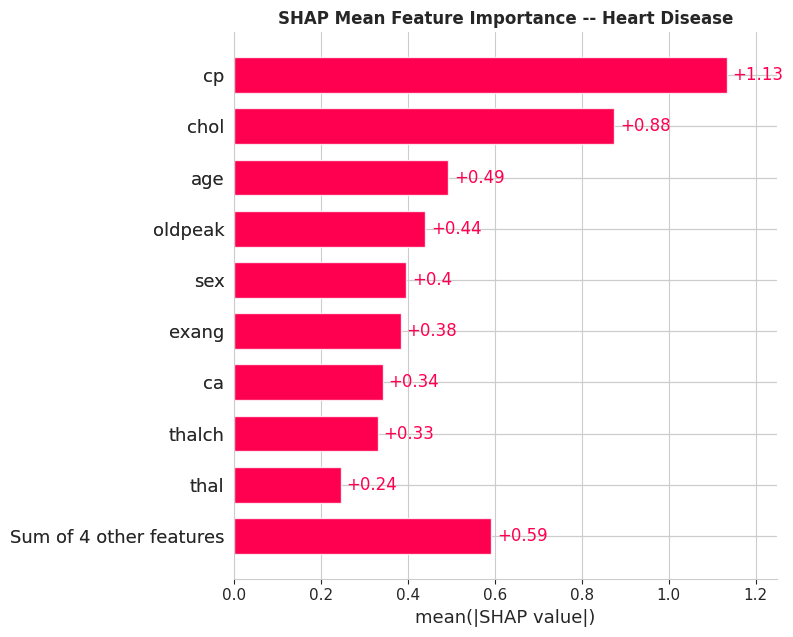

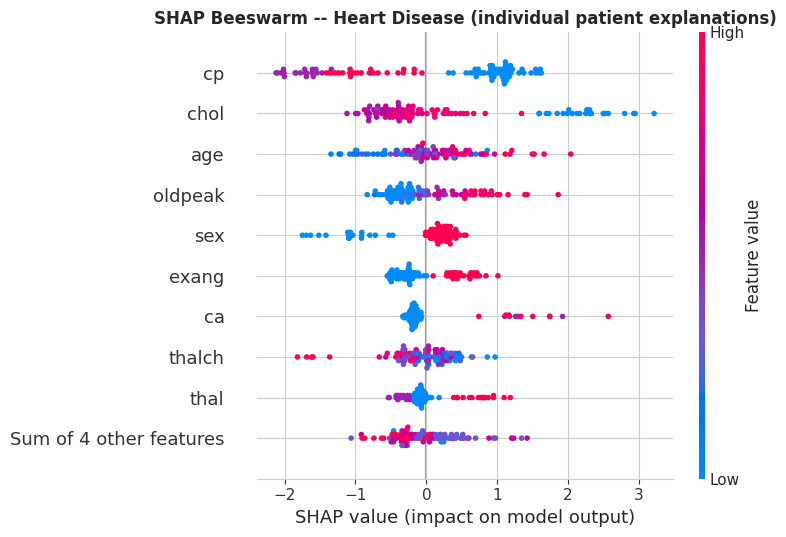

In [ ]:
gc.collect(); plt.close("all")
model_s = best_gb['Heart Disease']
explainer = shap.TreeExplainer(model_s)
sv = explainer.shap_values(Xte_h.iloc[:100].reset_index(drop=True))
if isinstance(sv, list): sv = sv[1]
shap_exp = shap.Explanation(values=sv, data=Xte_h.iloc[:100].reset_index(drop=True).values, feature_names=feat_h)

plt.figure()
shap.plots.bar(shap_exp, show=False)
plt.title("SHAP Mean Feature Importance -- Heart Disease", fontweight="bold", fontsize=12)
plt.tight_layout();
plt.show()

plt.figure()
shap.plots.beeswarm(shap_exp, show=False)
plt.title("SHAP Beeswarm -- Heart Disease (individual patient explanations)", fontweight="bold", fontsize=12)
plt.tight_layout();
plt.show()

del model_s, explainer, sv, shap_exp
gc.collect(); plt.close("all")

### 10.3 — SHAP: Kidney Disease

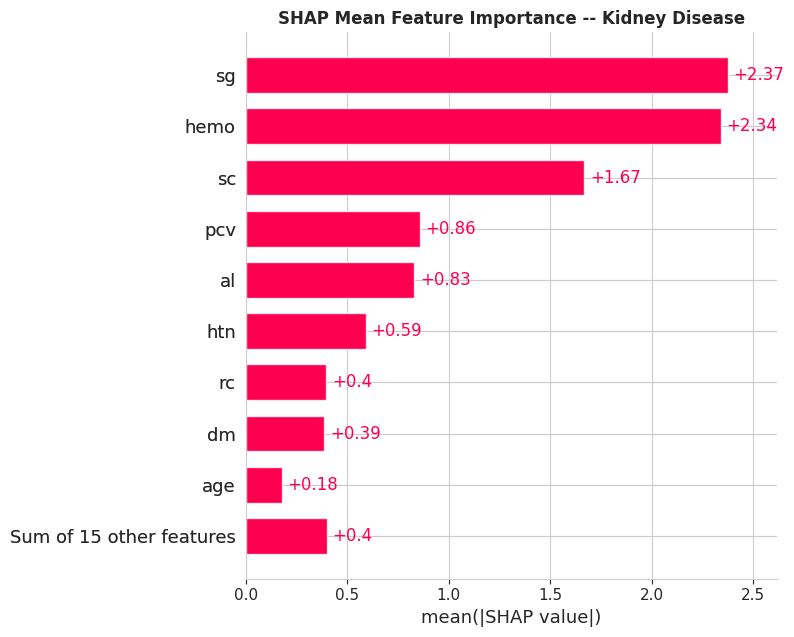

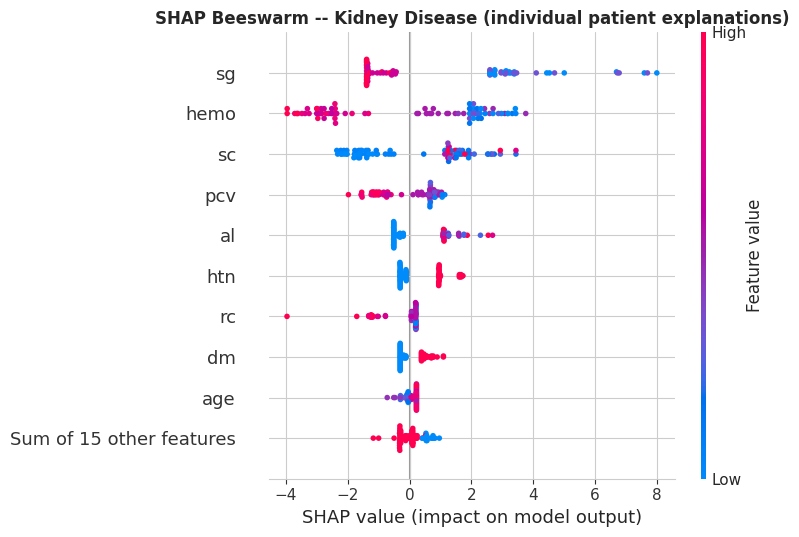

In [ ]:
gc.collect(); plt.close("all")
model_s = best_gb['Kidney Disease']
explainer = shap.TreeExplainer(model_s)
sv = explainer.shap_values(Xte_k.iloc[:100].reset_index(drop=True))
if isinstance(sv, list): sv = sv[1]
shap_exp = shap.Explanation(values=sv, data=Xte_k.iloc[:100].reset_index(drop=True).values, feature_names=feat_k)

plt.figure()
shap.plots.bar(shap_exp, show=False)
plt.title("SHAP Mean Feature Importance -- Kidney Disease", fontweight="bold", fontsize=12)
plt.tight_layout();
plt.show()

plt.figure()
shap.plots.beeswarm(shap_exp, show=False)
plt.title("SHAP Beeswarm -- Kidney Disease (individual patient explanations)", fontweight="bold", fontsize=12)
plt.tight_layout();
plt.show()

del model_s, explainer, sv, shap_exp
gc.collect(); plt.close("all")

## Step 11 — Save Trained Models



In [ ]:
import joblib
import os
import zipfile

# --- Save tuned models ---
joblib.dump(best_gb['Diabetes'],       "diabetes_model.pkl")
joblib.dump(best_gb['Heart Disease'],  "heart_model.pkl")
joblib.dump(best_gb['Kidney Disease'], "kidney_model.pkl")

# --- Save scalers ---
joblib.dump(scaler_d, "scaler_diabetes.pkl")
joblib.dump(scaler_h, "scaler_heart.pkl")
joblib.dump(scaler_k, "scaler_kidney.pkl")

# --- Save imputers ---
joblib.dump(imp_d, "imputer_diabetes.pkl")
joblib.dump(imp_h, "imputer_heart.pkl")
joblib.dump(imp_k, "imputer_kidney.pkl")

# --- List of files to zip ---
files_to_zip = [
    'diabetes_model.pkl',  'heart_model.pkl',  'kidney_model.pkl',
    'scaler_diabetes.pkl', 'scaler_heart.pkl', 'scaler_kidney.pkl',
    'imputer_diabetes.pkl','imputer_heart.pkl','imputer_kidney.pkl',
]

# --- Create ZIP file ---
zip_filename = "all_models_bundle.zip"

with zipfile.ZipFile(zip_filename, 'w', compression=zipfile.ZIP_DEFLATED) as z:
    for file in files_to_zip:
        if os.path.exists(file):
            z.write(file)
        else:
            print(f"⚠️ Missing file: {file}")

print(f"\n✅ All files zipped into '{zip_filename}'")

# --- Optional: show sizes ---
print("\nSaved files:")
for f in files_to_zip:
    size = os.path.getsize(f) if os.path.exists(f) else 0
    print(f"  {f:30s}  {size:>8,} bytes")


✅ All files zipped into 'all_models_bundle.zip'

Saved files:
  diabetes_model.pkl               809,672 bytes
  heart_model.pkl                  433,320 bytes
  kidney_model.pkl                 125,720 bytes
  scaler_diabetes.pkl                1,159 bytes
  scaler_heart.pkl                   1,263 bytes
  scaler_kidney.pkl                  1,575 bytes
  imputer_diabetes.pkl                 903 bytes
  imputer_heart.pkl                    943 bytes
  imputer_kidney.pkl                 1,063 bytes
